<a href="https://colab.research.google.com/github/Rima-fathallah/bird-behavior-ai/blob/main/02_behavior_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install all the libraries you need for this project
!pip install ultralytics pytorchvideo grad-cam shap matplotlib seaborn opencv-python -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Go to your Google Drive folder
os.makedirs('/content/drive/MyDrive/wetlandbirds', exist_ok=True)
os.chdir('/content/drive/MyDrive/wetlandbirds')

# Download the dataset from GitHub
!git clone https://github.com/3dperceptionlab/Visual-WetlandBirds
print("✅ Dataset downloaded!")

fatal: destination path 'Visual-WetlandBirds' already exists and is not an empty directory.
✅ Dataset downloaded!


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/wetlandbirds/Visual-WetlandBirds'

# Print everything inside the dataset folder
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    if level < 2:  # only show files 2 levels deep
        for file in files[:5]:  # show first 5 files only
            print(f'{indent}  📄 {file}')

📁 Visual-WetlandBirds/
  📄 .gitignore
  📄 Dockerfile
  📄 LICENSE
  📄 README.md
  📁 .git/
    📄 description
    📄 config
    📄 packed-refs
    📄 HEAD
    📄 index
    📁 branches/
    📁 info/
    📁 hooks/
    📁 refs/
      📁 heads/
      📁 tags/
      📁 remotes/
        📁 origin/
    📁 objects/
      📁 pack/
      📁 info/
    📁 logs/
      📁 refs/
        📁 remotes/
          📁 origin/
        📁 heads/
  📁 .assets/
    📄 activities.png
  📁 behavior_detection/
    📄 compute_stats.py
    📄 dataset.py
    📄 main.py
    📄 model.py
    📄 test.py
  📁 species_classification/
    📄 LICENSE.md
    📄 README.md
    📄 benchmarks.py
    📄 detect.py
    📄 detect_dual.py
    📁 classify/
    📁 data/
      📁 hyps/
      📁 images/
    📁 figure/
    📁 models/
      📁 detect/
      📁 hub/
      📁 panoptic/
      📁 segment/
    📁 panoptic/
    📁 scripts/
    📁 segment/
    📁 tools/
    📁 utils/
      📁 loggers/
        📁 clearml/
        📁 comet/
        📁 wandb/
      📁 panoptic/
        📁 tal/
      📁 segme

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/wetlandbirds/Visual-WetlandBirds'

# Check inside behavior_detection folder
print("=== behavior_detection folder ===")
for item in os.listdir(f'{dataset_path}/behavior_detection'):
    print(f"  {item}")

print("\n=== species_classification/data folder ===")
data_path = f'{dataset_path}/species_classification/data'
if os.path.exists(data_path):
    for item in os.listdir(data_path):
        print(f"  {item}")
else:
    print("  data folder is empty or missing")

=== behavior_detection folder ===
  compute_stats.py
  dataset.py
  main.py
  model.py
  test.py

=== species_classification/data folder ===
  coco.yaml
  coco2.yaml
  hyps
  images


In [ ]:
import os

images_path = '/content/drive/MyDrive/wetlandbirds/Visual-WetlandBirds/species_classification/data/images'

# Count files inside
all_files = []
for root, dirs, files in os.walk(images_path):
    for f in files:
        all_files.append(f)

print(f"Total files found: {len(all_files)}")

# Show first 10 files if any exist
if all_files:
    print("\nFirst 10 files:")
    for f in all_files[:10]:
        print(f"  {f}")
else:
    print("❌ Folder is empty — no image data here")

Total files found: 1

First 10 files:
  horses.jpg


In [ ]:
readme_path = '/content/drive/MyDrive/wetlandbirds/Visual-WetlandBirds/README.md'

with open(readme_path, 'r') as f:
    content = f.read()

print(content)

# Visual WetlandBirds Dataset

This is the official repository for 
<br/> **<u>Visual WetlandBirds Dataset: Bird Species Identification and Behaviour Recognition in Videos</u>**
<br/> **Javier Rodriguez-Juan, David Ortiz-Perez, Manuel Benavent-Lledo, David Mulero-Pérez, Pablo Ruiz-Ponce, Adrian Orihuela-Torres, Jose Garcia-Rodriguez and Esther Sebastián-González**
<br/> *University of Alicante*

## Contents

1. [Abstract](#abstract)
2. [Data](#data)
2. [Species classification](#species-classification)
3. [Behavior detection](#behavior-detection)
4. [Troubleshooting](#behavior-detection)
5. [Citation](#citation)
6. [License](#license)
7. [Acknowledgements](#acknowledgements)


## Abstract 

Animal monitoring is a vital field of study, particularly in light of the current biodiversity loss crisis. Data collected through monitoring can provide essential insights and information for decision-making aimed at preserving global biodiversity. Moreover, birds may also respond to human impacts i

In [ ]:
!pip install zenodo-get -q
print("✅ Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.1 MB/s eta 0:00:00
✅ Done


In [ ]:
import os

# Create a dedicated folder for the real data
os.makedirs('/content/drive/MyDrive/wetlandbirds/dataset', exist_ok=True)
os.chdir('/content/drive/MyDrive/wetlandbirds/dataset')

# Download everything from Zenodo
!zenodo_get 10.5281/zenodo.14355257

print("✅ Download complete!")

INFO: Output directory: /content/drive/MyDrive/wetlandbirds/dataset
INFO: Title: Visual WetlandBirds Dataset: Bird Species Identification and Behaviour Recognition in Videos
INFO: Total size: 9.4 GB
INFO: Number of files: 6
SUCCESS: All specified files have been processed.
✅ Download complete!


In [ ]:
import os

data_path = '/content/drive/MyDrive/wetlandbirds/dataset'

all_items = os.listdir(data_path)
print(f"Total items downloaded: {len(all_items)}")
print()
for item in all_items:
    print(f"  {item}")

Total items downloaded: 6

  species_ID.csv
  crops.csv
  behaviors_ID.csv
  splits.json
  bounding_boxes.csv
  videos.zip


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/wetlandbirds/dataset/videos.zip'
extract_path = '/content/drive/MyDrive/wetlandbirds/dataset/'

print("⏳ Unzipping videos... please wait")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Done! Videos extracted.")

⏳ Unzipping videos... please wait
✅ Done! Videos extracted.


In [ ]:
import pandas as pd
import json
import os

base = '/content/drive/MyDrive/wetlandbirds/dataset'

# --- Fix bounding boxes: try semicolon separator ---
print("=== Trying to read bounding_boxes.csv ===")
try:
    bbox = pd.read_csv(f'{base}/bounding_boxes.csv', sep=';')
    print("✅ Loaded with semicolon separator")
except:
    bbox = pd.read_csv(f'{base}/bounding_boxes.csv', sep=',', on_bad_lines='skip')
    print("✅ Loaded (skipped bad lines)")

print(f"Total rows: {len(bbox)}")
print(f"Columns: {list(bbox.columns)}")
print("\nFirst 5 rows:")
print(bbox.head())

# --- Check crops.csv too ---
print("\n=== crops.csv ===")
try:
    crops = pd.read_csv(f'{base}/crops.csv', sep=';')
    print("✅ Loaded with semicolon")
except:
    crops = pd.read_csv(f'{base}/crops.csv', on_bad_lines='skip')
print(f"Total rows: {len(crops)}")
print(f"Columns: {list(crops.columns)}")
print(crops.head())

# --- Check videos folder ---
print("\n=== Videos folder ===")
found = False
for folder in os.listdir(base):
    full = os.path.join(base, folder)
    if os.path.isdir(full):
        files = os.listdir(full)
        print(f"📁 {folder}/ → {len(files)} files")
        for f in files[:3]:
            print(f"     {f}")
        found = True
if not found:
    print("No subfolders found yet — videos may still be extracting")

=== Trying to read bounding_boxes.csv ===
✅ Loaded with semicolon separator
Total rows: 120694
Columns: ['species_id', 'species', 'video_name', 'frame', 'bounding_boxes']

First 5 rows:
   species_id        species         video_name  frame  \
0           0  White Wagtail  001-white_wagtail      0   
1           0  White Wagtail  001-white_wagtail      1   
2           0  White Wagtail  001-white_wagtail      2   
3           0  White Wagtail  001-white_wagtail      3   
4           0  White Wagtail  001-white_wagtail      4   

                             bounding_boxes  
0  [(364.62, 191.11, 574.08, 394.75, 1, 0)]  
1     [(364.5, 191.0, 573.75, 394.5, 1, 0)]  
2     [(364.5, 185.0, 573.75, 388.5, 1, 0)]  
3   [(363.0, 182.25, 572.25, 385.75, 1, 0)]  
4   [(362.75, 176.25, 572.0, 379.75, 1, 0)]  

=== crops.csv ===
✅ Loaded with semicolon
Total rows: 1469
Columns: ['video_name', 'bird_id', 'species_id', 'action_id', 'start_frame', 'end_frame']
          video_name  bird_id  species_

In [ ]:
import os

video_path = '/content/drive/MyDrive/wetlandbirds/dataset/videos'

if os.path.exists(video_path):
    videos = os.listdir(video_path)
    print(f"✅ Total videos: {len(videos)}")
    print("\nFirst 10 videos:")
    for v in videos[:10]:
        print(f"  {v}")
else:
    # Maybe they extracted into a subfolder
    print("Looking for videos folder...")
    for item in os.listdir('/content/drive/MyDrive/wetlandbirds/dataset'):
        print(f"  {item}")

✅ Total videos: 178

First 10 videos:
  001-white_wagtail.mp4
  002-squacco_heron.mp4
  003-squacco_heron.mp4
  004-squacco_heron.mp4
  005-squacco_heron.mp4
  006-yellow_legged_gull.mp4
  007-yellow_legged_gull.mp4
  008-yellow_legged_gull.mp4
  009-yellow_legged_gull.mp4
  010-yellow_legged_gull.mp4


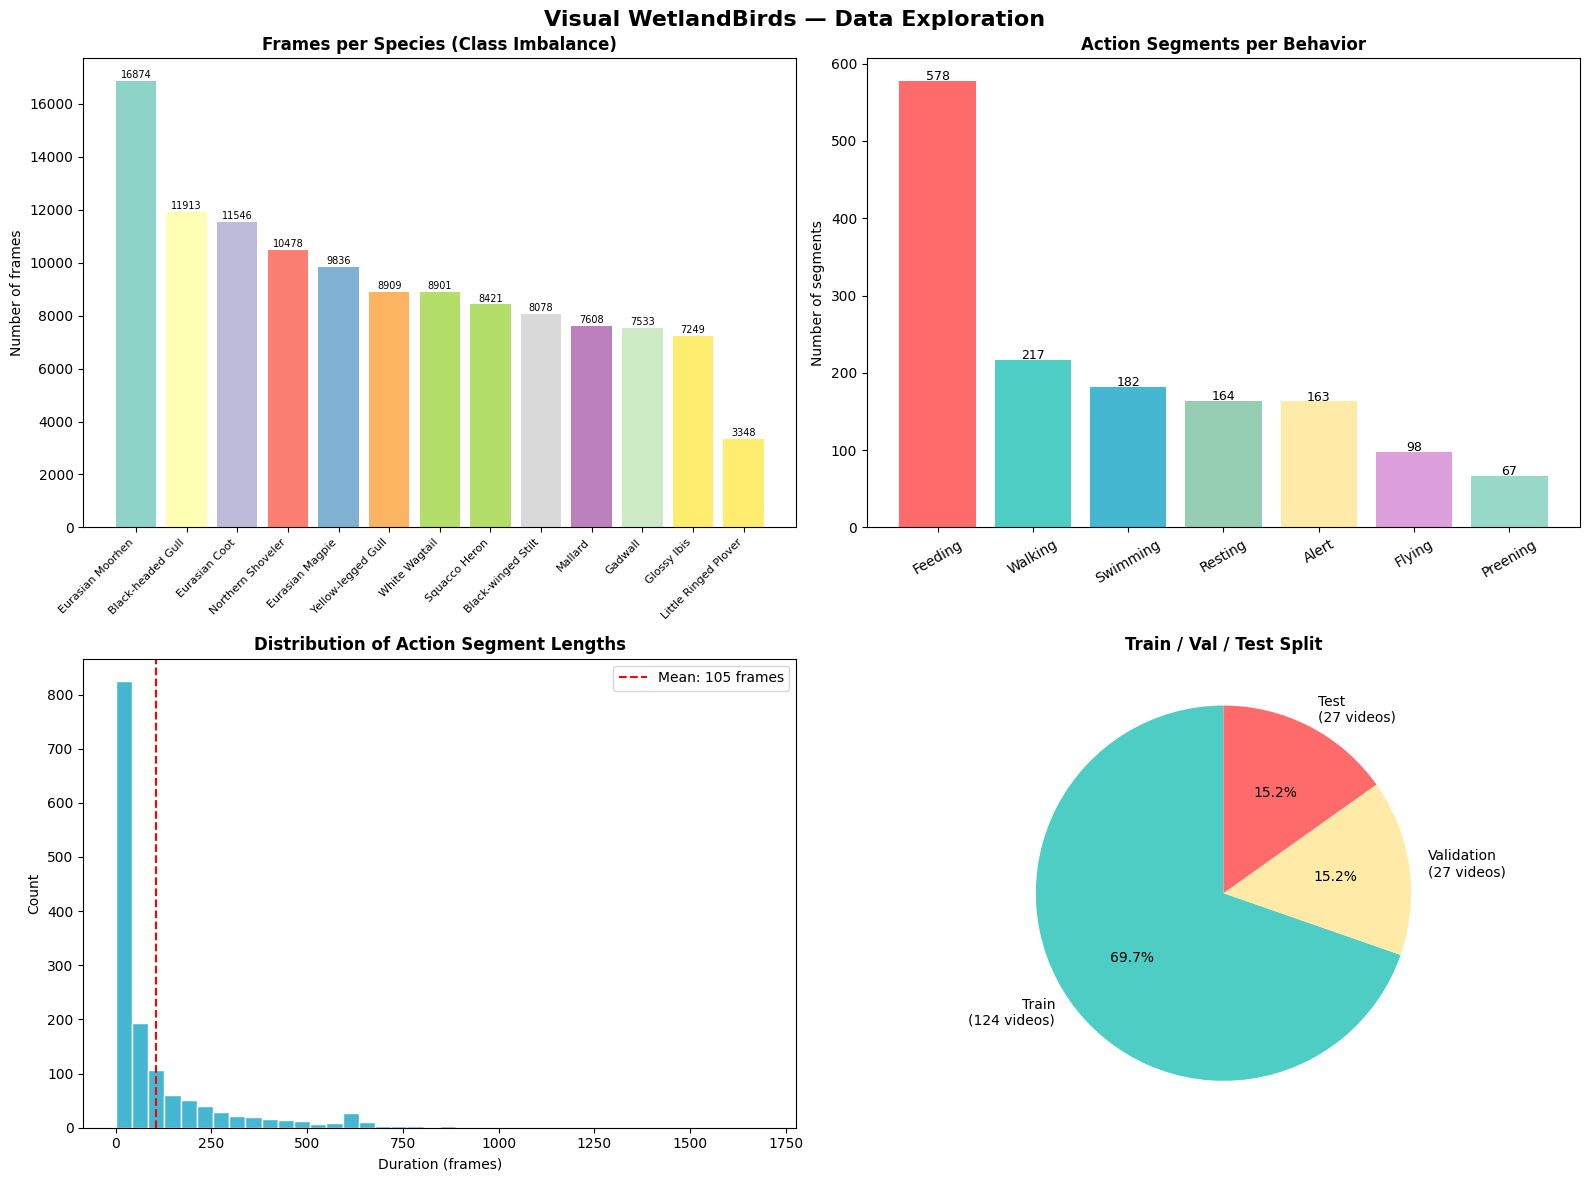

✅ Chart saved to your Google Drive!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import cv2
import numpy as np
import ast
import os

base = '/content/drive/MyDrive/wetlandbirds/dataset'

# Reload everything cleanly
bbox = pd.read_csv(f'{base}/bounding_boxes.csv', sep=';')
crops = pd.read_csv(f'{base}/crops.csv', sep=';')
species_df = pd.read_csv(f'{base}/species_ID.csv')
behaviors_df = pd.read_csv(f'{base}/behaviors_ID.csv')
with open(f'{base}/splits.json') as f:
    splits = json.load(f)

# ─────────────────────────────────────────
# CHART 1: How many frames per species?
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visual WetlandBirds — Data Exploration', fontsize=16, fontweight='bold')

species_counts = bbox.groupby('species')['frame'].count().sort_values(ascending=False)
axes[0,0].bar(range(len(species_counts)), species_counts.values,
              color=plt.cm.Set3(np.linspace(0, 1, len(species_counts))))
axes[0,0].set_xticks(range(len(species_counts)))
axes[0,0].set_xticklabels(species_counts.index, rotation=45, ha='right', fontsize=8)
axes[0,0].set_title('Frames per Species (Class Imbalance)', fontweight='bold')
axes[0,0].set_ylabel('Number of frames')
for i, v in enumerate(species_counts.values):
    axes[0,0].text(i, v + 100, str(v), ha='center', fontsize=7)

# ─────────────────────────────────────────
# CHART 2: How many action segments per behavior?
# ─────────────────────────────────────────
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
crops['behavior_name'] = crops['action_id'].map(behavior_map)
behavior_counts = crops['behavior_name'].value_counts()

colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8']
axes[0,1].bar(behavior_counts.index, behavior_counts.values, color=colors[:len(behavior_counts)])
axes[0,1].set_title('Action Segments per Behavior', fontweight='bold')
axes[0,1].set_ylabel('Number of segments')
axes[0,1].tick_params(axis='x', rotation=30)
for i, (idx, v) in enumerate(behavior_counts.items()):
    axes[0,1].text(i, v + 1, str(v), ha='center', fontsize=9)

# ─────────────────────────────────────────
# CHART 3: How long are the action segments (frames)?
# ─────────────────────────────────────────
crops['duration'] = crops['end_frame'] - crops['start_frame']
axes[1,0].hist(crops['duration'], bins=40, color='#45B7D1', edgecolor='white')
axes[1,0].set_title('Distribution of Action Segment Lengths', fontweight='bold')
axes[1,0].set_xlabel('Duration (frames)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(crops['duration'].mean(), color='red', linestyle='--',
                   label=f"Mean: {crops['duration'].mean():.0f} frames")
axes[1,0].legend()

# ─────────────────────────────────────────
# CHART 4: Train / Val / Test split sizes
# ─────────────────────────────────────────
split_sizes = {
    'Train': len(splits['train_set']),
    'Validation': len(splits['val_set']),
    'Test': len(splits['test_set'])
}
axes[1,1].pie(split_sizes.values(),
              labels=[f"{k}\n({v} videos)" for k,v in split_sizes.items()],
              colors=['#4ECDC4','#FFEAA7','#FF6B6B'],
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Train / Val / Test Split', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wetlandbirds/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to your Google Drive!")

In [ ]:
from IPython.display import Video

video_path = '/content/drive/MyDrive/wetlandbirds/dataset/videos/001-white_wagtail.mp4'
Video(video_path, width=500)

In [ ]:
print("=" * 50)
print("      DATASET SUMMARY")
print("=" * 50)
print(f"  Total videos:          178")
print(f"  Total annotated frames: {len(bbox):,}")
print(f"  Total action segments:  {len(crops):,}")
print(f"  Number of species:      {bbox['species'].nunique()}")
print(f"  Number of behaviors:    {crops['behavior_name'].nunique()}")
print(f"  Train videos:           {len(splits['train_set'])}")
print(f"  Val videos:             {len(splits['val_set'])}")
print(f"  Test videos:            {len(splits['test_set'])}")
print()
print("  Most common species:  ", species_counts.index[0], f"({species_counts.iloc[0]:,} frames)")
print("  Rarest species:       ", species_counts.index[-1], f"({species_counts.iloc[-1]:,} frames)")
print()
print("  Most common behavior: ", behavior_counts.index[0], f"({behavior_counts.iloc[0]} segments)")
print("  Rarest behavior:      ", behavior_counts.index[-1], f"({behavior_counts.iloc[-1]} segments)")
print()
print("  Avg action duration:  ", f"{crops['duration'].mean():.0f} frames")
print("  Max action duration:  ", f"{crops['duration'].max()} frames")
print("  Min action duration:  ", f"{crops['duration'].min()} frames")
print("=" * 50)

      DATASET SUMMARY
  Total videos:          178
  Total annotated frames: 120,694
  Total action segments:  1,469
  Number of species:      13
  Number of behaviors:    7
  Train videos:           124
  Val videos:             27
  Test videos:            27

  Most common species:   Eurasian Moorhen (16,874 frames)
  Rarest species:        Little Ringed Plover (3,348 frames)

  Most common behavior:  Feeding (578 segments)
  Rarest behavior:       Preening (67 segments)

  Avg action duration:   105 frames
  Max action duration:   1693 frames
  Min action duration:   0 frames


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import json

base = '/content/drive/MyDrive/wetlandbirds/dataset'

crops = pd.read_csv(f'{base}/crops.csv', sep=';')
bbox = pd.read_csv(f'{base}/bounding_boxes.csv', sep=';')
behaviors_df = pd.read_csv(f'{base}/behaviors_ID.csv')
species_df = pd.read_csv(f'{base}/species_ID.csv')

behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
crops['behavior_name'] = crops['action_id'].map(behavior_map)

# ── Behavior class weights ──
behavior_labels = crops['action_id'].values
behavior_classes = np.unique(behavior_labels)
behavior_weights = compute_class_weight(
    class_weight='balanced',
    classes=behavior_classes,
    y=behavior_labels
)
print("=== BEHAVIOR CLASS WEIGHTS ===")
print("(higher = model must pay more attention to this class)")
for cls, w in zip(behavior_classes, behavior_weights):
    name = behavior_map[cls]
    bar = "█" * int(w * 5)
    print(f"  {name:<15} (id={cls})  weight={w:.3f}  {bar}")

# ── Species class weights ──
species_labels = bbox['species_id'].values
species_classes = np.unique(species_labels)
species_map = dict(zip(species_df['id'], species_df['species']))
species_weights = compute_class_weight(
    class_weight='balanced',
    classes=species_classes,
    y=species_labels
)
print("\n=== SPECIES CLASS WEIGHTS ===")
for cls, w in zip(species_classes, species_weights):
    name = species_map[cls]
    bar = "█" * int(w * 5)
    print(f"  {name:<25} (id={cls})  weight={w:.3f}  {bar}")

# ── Save weights for later use in training ──
import json
weights_to_save = {
    'behavior_weights': dict(zip([int(c) for c in behavior_classes],
                                  [float(w) for w in behavior_weights])),
    'species_weights':  dict(zip([int(c) for c in species_classes],
                                  [float(w) for w in species_weights]))
}
with open(f'{base}/class_weights.json', 'w') as f:
    json.dump(weights_to_save, f, indent=2)

print("\n✅ Class weights saved to class_weights.json")
print("   We will load these during model training to fix imbalance.")

=== BEHAVIOR CLASS WEIGHTS ===
(higher = model must pay more attention to this class)
  Feeding         (id=0)  weight=0.363  █
  Preening        (id=1)  weight=3.132  ███████████████
  Swimming        (id=2)  weight=1.153  █████
  Walking         (id=3)  weight=0.967  ████
  Alert           (id=4)  weight=1.287  ██████
  Flying          (id=5)  weight=2.141  ██████████
  Resting         (id=6)  weight=1.280  ██████

=== SPECIES CLASS WEIGHTS ===
  White Wagtail             (id=0)  weight=1.043  █████
  Glossy Ibis               (id=1)  weight=1.281  ██████
  Squacco Heron             (id=2)  weight=1.103  █████
  Black-winged Stilt        (id=3)  weight=1.149  █████
  Yellow-legged Gull        (id=4)  weight=1.042  █████
  Northern Shoveler         (id=5)  weight=0.886  ████
  Black-headed Gull         (id=6)  weight=0.779  ███
  Eurasian Coot             (id=7)  weight=0.804  ████
  Little Ringed Plover      (id=8)  weight=2.773  █████████████
  Eurasian Moorhen          (id=9)  weig

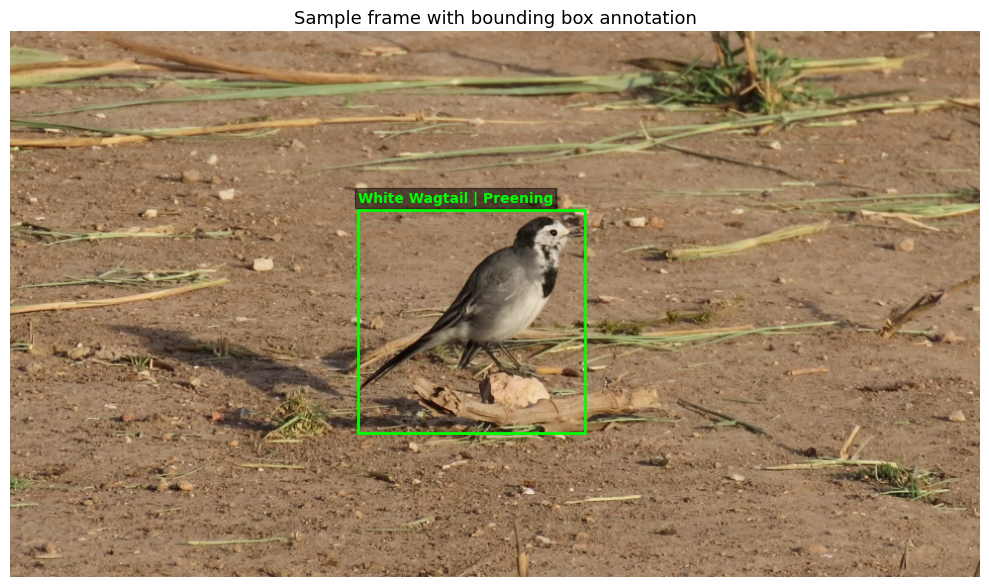

✅ Sample frame saved!


In [ ]:
import cv2
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

base = '/content/drive/MyDrive/wetlandbirds/dataset'
bbox = pd.read_csv(f'{base}/bounding_boxes.csv', sep=';')

video_path = f'{base}/videos/001-white_wagtail.mp4'
cap = cv2.VideoCapture(video_path)

# Read frame 50
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Get bounding box for this frame
row = bbox[(bbox['video_name'] == '001-white_wagtail') & (bbox['frame'] == 50)].iloc[0]
boxes = ast.literal_eval(row['bounding_boxes'])

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(frame_rgb)

behavior_map = {0:'Feeding',1:'Preening',2:'Swimming',3:'Walking',4:'Alert',5:'Flying',6:'Resting'}

for box in boxes:
    x1, y1, x2, y2, behavior_id, bird_id = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    label = f"White Wagtail | {behavior_map[int(behavior_id)]}"
    ax.text(x1, y1 - 8, label, color='lime',
            fontsize=10, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=2))

ax.set_title('Sample frame with bounding box annotation', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wetlandbirds/sample_frame.png', dpi=150)
plt.show()
print("✅ Sample frame saved!")

In [ ]:
import os
import shutil

# Delete the videos folder from Drive (too large)
videos_in_drive = '/content/drive/MyDrive/wetlandbirds/dataset/videos'
zip_in_drive    = '/content/drive/MyDrive/wetlandbirds/dataset/videos.zip'

if os.path.exists(videos_in_drive):
    shutil.rmtree(videos_in_drive)
    print("✅ videos/ folder deleted from Drive")

if os.path.exists(zip_in_drive):
    os.remove(zip_in_drive)
    print("✅ videos.zip deleted from Drive")

# Check how much is left in Drive
result = os.popen('du -sh /content/drive/MyDrive/wetlandbirds/').read()
print(f"\nDrive usage now: {result}")

✅ videos/ folder deleted from Drive
✅ videos.zip deleted from Drive

Drive usage now: 20M	/content/drive/MyDrive/wetlandbirds/



In [ ]:
import os

# Create folder directly on Colab machine (not Drive)
os.makedirs('/content/wetlandbirds_videos', exist_ok=True)
os.chdir('/content/wetlandbirds_videos')

print("⏳ Downloading videos to Colab machine (not Drive)...")
print("   This takes 5-10 minutes...\n")

!zenodo_get 10.5281/zenodo.14355257 --record=14355257 -o /content/wetlandbirds_videos

print("\n✅ Done!")

⏳ Downloading videos to Colab machine (not Drive)...
   This takes 5-10 minutes...

INFO: Output directory: /content/wetlandbirds_videos
INFO: Title: Visual WetlandBirds Dataset: Bird Species Identification and Behaviour Recognition in Videos
INFO: Total size: 9.4 GB
INFO: Number of files: 6
SUCCESS: All specified files have been processed.

✅ Done!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Small files go to Drive (permanent)
os.makedirs('/content/drive/MyDrive/wetlandbirds', exist_ok=True)

# Videos go to Colab machine only (temporary, fast)
os.makedirs('/content/videos', exist_ok=True)

print("✅ Ready")
print("Drive path (for CSVs and notebooks):", '/content/drive/MyDrive/wetlandbirds')
print("Video path (Colab machine only):    ", '/content/videos')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready
Drive path (for CSVs and notebooks): /content/drive/MyDrive/wetlandbirds
Video path (Colab machine only):     /content/videos


In [ ]:
!pip install zenodo-get -q
print("✅ Done")

✅ Done


In [ ]:
import os
os.chdir('/content/drive/MyDrive/wetlandbirds')

# Download everything from Zenodo
!zenodo_get 10.5281/zenodo.14355257

print("✅ Download complete!")

INFO: Output directory: /content/drive/MyDrive/wetlandbirds
INFO: Title: Visual WetlandBirds Dataset: Bird Species Identification and Behaviour Recognition in Videos
INFO: Total size: 9.4 GB
INFO: Number of files: 6
SUCCESS: All specified files have been processed.
✅ Download complete!


In [ ]:
import shutil
import os

# Move the zip to Colab machine
print("⏳ Moving videos.zip to Colab machine...")
shutil.move(
    '/content/drive/MyDrive/wetlandbirds/videos.zip',
    '/content/videos.zip'
)
print("✅ Moved!")

# Check what stays in Drive (should be only small CSV files)
print("\nFiles remaining in Drive:")
for f in os.listdir('/content/drive/MyDrive/wetlandbirds'):
    size = os.path.getsize(f'/content/drive/MyDrive/wetlandbirds/{f}')
    print(f"  {f}  ({size/1024:.1f} KB)")

⏳ Moving videos.zip to Colab machine...
✅ Moved!

Files remaining in Drive:
  species_ID.csv  (0.2 KB)
  crops.csv  (48.1 KB)
  behaviors_ID.csv  (0.1 KB)
  splits.json  (3.9 KB)
  bounding_boxes.csv  (10503.3 KB)


In [ ]:
import zipfile

print("⏳ Unzipping videos... please wait (3-5 minutes)")

with zipfile.ZipFile('/content/videos.zip', 'r') as z:
    z.extractall('/content/')

# Count videos
videos = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
print(f"✅ {len(videos)} videos ready!")
print("First 3:", videos[:3])

⏳ Unzipping videos... please wait (3-5 minutes)
✅ 178 videos ready!
First 3: ['114-eurasian_moorhen.mp4', '115-eurasian_moorhen.mp4', '034-gadwall.mp4']


In [ ]:
import os

drive_path = '/content/drive/MyDrive/wetlandbirds'
video_path = '/content/videos'

print("=== DRIVE (permanent small files) ===")
for f in os.listdir(drive_path):
    size = os.path.getsize(f'{drive_path}/{f}')
    print(f"  ✅ {f}  ({size/1024:.1f} KB)")

print("\n=== COLAB MACHINE (videos) ===")
mp4s = [f for f in os.listdir(video_path) if f.endswith('.mp4')]
print(f"  ✅ {len(mp4s)} video files ready")

=== DRIVE (permanent small files) ===
  ✅ species_ID.csv  (0.2 KB)
  ✅ crops.csv  (48.1 KB)
  ✅ behaviors_ID.csv  (0.1 KB)
  ✅ splits.json  (3.9 KB)
  ✅ bounding_boxes.csv  (10503.3 KB)

=== COLAB MACHINE (videos) ===
  ✅ 178 video files ready


In [ ]:
!pip install torch torchvision scikit-learn matplotlib tqdm -q
print("✅ Done")

✅ Done


In [ ]:
import os, json, ast
import numpy as np
import pandas as pd
import torch

drive = '/content/drive/MyDrive/wetlandbirds'
video_dir = '/content/videos'

crops        = pd.read_csv(f'{drive}/crops.csv', sep=';')
bbox         = pd.read_csv(f'{drive}/bounding_boxes.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
species_df   = pd.read_csv(f'{drive}/species_ID.csv')

with open(f'{drive}/splits.json') as f:
    splits = json.load(f)

behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))

print("✅ All files loaded")
print(f"   Clips: {len(crops)}")
print(f"   Frames: {len(bbox):,}")

✅ All files loaded
   Clips: 1469
   Frames: 120,694


In [ ]:
import cv2
from torch.utils.data import Dataset, DataLoader

class WetlandBirdsDataset(Dataset):

    def __init__(self, crops_df, bbox_df, video_dir,
                 split_videos, n_frames=16, img_size=112,
                 augment=False):

        self.clips     = crops_df[
            crops_df['video_name'].isin(split_videos)
        ].reset_index(drop=True)
        self.bbox_df   = bbox_df
        self.video_dir = video_dir
        self.n_frames  = n_frames
        self.img_size  = img_size
        self.augment   = augment

        # Pre-index bbox by video+frame for speed
        self.bbox_index = bbox_df.set_index(
            ['video_name','frame'])

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        row        = self.clips.iloc[idx]
        video_name = row['video_name']
        bird_id    = int(row['bird_id'])
        action_id  = int(row['action_id'])
        start      = int(row['start_frame'])
        end        = int(row['end_frame'])

        if end <= start:
            end = start + 1

        frame_ids = np.linspace(start, end-1,
                                self.n_frames, dtype=int)

        video_path = os.path.join(self.video_dir,
                                  f'{video_name}.mp4')
        cap = cv2.VideoCapture(video_path)
        frames = []

        for fid in frame_ids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
            ret, frame = cap.read()

            if not ret:
                frame = np.zeros(
                    (self.img_size, self.img_size, 3),
                    dtype=np.uint8)
            else:
                # Crop bird using bounding box
                try:
                    bb_row = self.bbox_index.loc[
                        (video_name, int(fid))]
                    if isinstance(bb_row, pd.DataFrame):
                        bb_row = bb_row.iloc[0]
                    boxes = ast.literal_eval(
                        bb_row['bounding_boxes'])
                    bird_box = None
                    for box in boxes:
                        if int(box[5]) == bird_id:
                            bird_box = box
                            break
                    if bird_box is None:
                        bird_box = boxes[0]
                    x1,y1,x2,y2 = (int(bird_box[0]),
                                   int(bird_box[1]),
                                   int(bird_box[2]),
                                   int(bird_box[3]))
                    h,w = frame.shape[:2]
                    x1,y1 = max(0,x1), max(0,y1)
                    x2,y2 = min(w,x2), min(h,y2)
                    if x2>x1 and y2>y1:
                        frame = frame[y1:y2, x1:x2]
                except (KeyError, IndexError):
                    pass

                frame = cv2.resize(
                    frame, (self.img_size, self.img_size))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Augmentation for training only
                if self.augment:
                    if np.random.rand() > 0.5:
                        frame = np.fliplr(frame).copy()
                    if np.random.rand() > 0.5:
                        brightness = np.random.uniform(0.8, 1.2)
                        frame = np.clip(
                            frame * brightness, 0, 255
                        ).astype(np.uint8)

            frames.append(frame)

        cap.release()

        clip = np.stack(frames)
        clip = torch.tensor(clip, dtype=torch.float32)
        clip = clip.permute(3,0,1,2)   # C,T,H,W
        clip = clip / 255.0

        mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1,1)
        std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1,1)
        clip = (clip - mean) / std

        return clip, torch.tensor(action_id, dtype=torch.long)

# Create datasets
train_ds = WetlandBirdsDataset(
    crops, bbox, video_dir,
    splits['train_set'], augment=True)
val_ds   = WetlandBirdsDataset(
    crops, bbox, video_dir,
    splits['val_set'], augment=False)
test_ds  = WetlandBirdsDataset(
    crops, bbox, video_dir,
    splits['test_set'], augment=False)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=8,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=8,
                          shuffle=False, num_workers=2)

print("✅ Datasets ready")
print(f"   Train clips: {len(train_ds)}")
print(f"   Val   clips: {len(val_ds)}")
print(f"   Test  clips: {len(test_ds)}")

# Quick test
clip, label = train_ds[0]
print(f"\n✅ Sample shape: {clip.shape}")
print(f"   Label: {label.item()} = {behavior_map[label.item()]}")

✅ Datasets ready
   Train clips: 878
   Val   clips: 341
   Test  clips: 250

✅ Sample shape: torch.Size([3, 16, 112, 112])
   Label: 4 = Alert


In [ ]:
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights

class BehaviorModel(nn.Module):
    """
    R3D-18: a 3D ResNet pretrained on Kinetics-400
    We replace the final layer to output 7 behavior classes
    This is much stronger than the Video ResNet baseline
    """
    def __init__(self, num_classes=7):
        super().__init__()

        # Load pretrained model
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)

        # Replace final layer for our 7 classes
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

model = BehaviorModel(num_classes=7).to(device)
print("✅ Model ready")

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params:     {total:,}")
print(f"   Trainable params: {trainable:,}")

✅ Using device: cuda
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:11<00:00, 11.9MB/s]


✅ Model ready
   Total params:     33,169,863
   Trainable params: 33,169,863


In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Class weights to handle imbalance
behavior_counts = crops['action_id'].value_counts().sort_index()
weights = 1.0 / behavior_counts.values
weights = weights / weights.sum() * len(weights)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

best_val_acc = 0.0
history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

print("🚀 Starting training...")
print("   Baseline to beat: 0.56 accuracy")
print("─" * 45)

for epoch in range(20):

    # ── Training ──
    model.train()
    train_loss = 0.0

    for clips, labels in tqdm(train_loader,
                               desc=f"Epoch {epoch+1:02d}/20",
                               leave=False):
        clips  = clips.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(clips)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validation ──
    model.eval()
    val_loss  = 0.0
    all_preds = []
    all_labels= []

    with torch.no_grad():
        for clips, labels in val_loader:
            clips  = clips.to(device)
            labels = labels.to(device)
            outputs = model(clips)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_acc'].append(val_acc)
    scheduler.step()

    # Save best model to Drive
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
            '/content/drive/MyDrive/wetlandbirds/best_model.pth')
        star = " ⭐ NEW BEST"
    else:
        star = ""

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {avg_train:.3f} | "
          f"Val Loss: {avg_val:.3f} | "
          f"Val Acc: {val_acc:.3f}{star}")

print(f"\n✅ Training complete!")
print(f"   Best validation accuracy: {best_val_acc:.3f}")
print(f"   Baseline was:             0.560")
if best_val_acc > 0.56:
    print(f"   🎉 We beat the baseline!")
else:
    print(f"   Keep going — we will improve this")

🚀 Starting training...
   Baseline to beat: 0.56 accuracy
─────────────────────────────────────────────


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


In [ ]:
import os

drive = '/content/drive/MyDrive/wetlandbirds'

print("Files in Drive:")
for f in os.listdir(drive):
    size = os.path.getsize(f'{drive}/{f}')
    print(f"  ✅ {f}  ({size/1024:.1f} KB)")

print("\nVideos on Colab machine:")
if os.path.exists('/content/videos'):
    mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
    print(f"  ✅ {len(mp4s)} videos found")
else:
    print("  ❌ Videos folder missing — need to re-download")

Files in Drive:
  ✅ species_ID.csv  (0.2 KB)
  ✅ crops.csv  (48.1 KB)
  ✅ behaviors_ID.csv  (0.1 KB)
  ✅ splits.json  (3.9 KB)
  ✅ bounding_boxes.csv  (10503.3 KB)

Videos on Colab machine:
  ❌ Videos folder missing — need to re-download


In [ ]:
import os

os.makedirs('/content/videos_zip', exist_ok=True)
os.chdir('/content/videos_zip')

print("⏳ Downloading videos... (5-10 minutes)")
!zenodo_get 10.5281/zenodo.14355257
print("✅ Download complete!")

⏳ Downloading videos... (5-10 minutes)
/bin/bash: line 1: zenodo_get: command not found
✅ Download complete!


In [ ]:
import zipfile, os

print("⏳ Unzipping...")
with zipfile.ZipFile('/content/videos_zip/videos.zip', 'r') as z:
    z.extractall('/content/')

mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
print(f"✅ {len(mp4s)} videos ready!")

⏳ Unzipping...


FileNotFoundError: [Errno 2] No such file or directory: '/content/videos_zip/videos.zip'

In [ ]:
import os

print("Searching for videos.zip...")
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.zip'):
            full_path = os.path.join(root, f)
            size = os.path.getsize(full_path)
            print(f"  Found: {full_path}  ({size/1024/1024:.0f} MB)")

Searching for videos.zip...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/projet rima (1).zip'

In [ ]:
import os

os.makedirs('/content/videos_zip', exist_ok=True)
os.chdir('/content/videos_zip')

print("⏳ Downloading from updated Zenodo record...")

!wget -O /content/videos_zip/videos.zip \
    "https://zenodo.org/records/15696105/files/videos.zip?download=1" \
    --progress=bar:force 2>&1 | tail -5

# Check size
if os.path.exists('/content/videos_zip/videos.zip'):
    size = os.path.getsize('/content/videos_zip/videos.zip')
    print(f"\nSize: {size/1024/1024:.0f} MB")
    if size > 100_000_000:
        print("✅ Download looks good!")
    else:
        print("❌ File too small — download failed")
else:
    print("❌ File not found")

⏳ Downloading from updated Zenodo record...

/content/videos_zip 100%[===================>]   8.78G  2.51MB/s    in 50m 32s 

2026-04-23 11:16:34 (2.97 MB/s) - ‘/content/videos_zip/videos.zip’ saved [9432614851/9432614851]


Size: 8996 MB
✅ Download looks good!


In [ ]:
import zipfile, os

print("⏳ Unzipping 8.78GB... (5-10 minutes)")

with zipfile.ZipFile('/content/videos_zip/videos.zip', 'r') as z:
    z.extractall('/content/')

# Check result
if os.path.exists('/content/videos'):
    mp4s = [f for f in os.listdir('/content/videos')
            if f.endswith('.mp4')]
    print(f"✅ {len(mp4s)} videos ready!")
else:
    # Maybe extracted to a different folder name
    print("Looking for extracted folder...")
    for item in os.listdir('/content'):
        if os.path.isdir(f'/content/{item}'):
            print(f"  📁 {item}/")

⏳ Unzipping 8.78GB... (5-10 minutes)
✅ 178 videos ready!


In [ ]:
import os, ast, cv2, json
import numpy as np
import pandas as pd
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
video_dir = '/content/videos'
clips_dir = '/content/clips'
os.makedirs(clips_dir, exist_ok=True)

crops = pd.read_csv(f'{drive}/crops.csv', sep=';')
bbox  = pd.read_csv(f'{drive}/bounding_boxes.csv', sep=';')

print("⏳ Indexing bounding boxes...")
bbox_index = bbox.set_index(['video_name','frame'])
print(f"✅ Ready — extracting {len(crops)} clips\n")

N_FRAMES = 16
IMG_SIZE = 112
saved, failed = 0, 0

for idx, row in tqdm(crops.iterrows(), total=len(crops),
                     desc="Extracting clips"):
    video_name = row['video_name']
    bird_id    = int(row['bird_id'])
    action_id  = int(row['action_id'])
    start      = int(row['start_frame'])
    end        = int(row['end_frame'])
    if end <= start:
        end = start + 1

    frame_ids  = np.linspace(start, end-1, N_FRAMES, dtype=int)
    video_path = os.path.join(video_dir, f'{video_name}.mp4')

    if not os.path.exists(video_path):
        failed += 1
        continue

    clip_folder = os.path.join(clips_dir, f'clip_{idx:05d}')
    os.makedirs(clip_folder, exist_ok=True)

    with open(os.path.join(clip_folder, 'label.txt'), 'w') as f:
        f.write(str(action_id))

    cap = cv2.VideoCapture(video_path)
    for i, fid in enumerate(frame_ids):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
        else:
            try:
                bb_row = bbox_index.loc[(video_name, int(fid))]
                if isinstance(bb_row, pd.DataFrame):
                    bb_row = bb_row.iloc[0]
                boxes = ast.literal_eval(bb_row['bounding_boxes'])
                bird_box = None
                for box in boxes:
                    if int(box[5]) == bird_id:
                        bird_box = box
                        break
                if bird_box is None:
                    bird_box = boxes[0]
                x1,y1,x2,y2 = (int(bird_box[0]), int(bird_box[1]),
                                int(bird_box[2]), int(bird_box[3]))
                h,w = frame.shape[:2]
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(w,x2), min(h,y2)
                if x2>x1 and y2>y1:
                    frame = frame[y1:y2, x1:x2]
            except (KeyError, IndexError):
                pass
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

        cv2.imwrite(
            os.path.join(clip_folder, f'frame_{i:02d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, 90]
        )
    cap.release()
    saved += 1

print(f"\n✅ Done!")
print(f"   Clips saved:  {saved}")
print(f"   Clips failed: {failed}")
print(f"   Disk used: {os.popen(f'du -sh {clips_dir}').read().strip()}")

⏳ Indexing bounding boxes...
✅ Ready — extracting 1469 clips



Extracting clips: 100%|██████████| 1469/1469 [2:17:54<00:00,  5.63s/it]



✅ Done!
   Clips saved:  1469
   Clips failed: 0
   Disk used: 177M	/content/clips


In [ ]:
import os, json

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

index = []
for clip_folder in sorted(os.listdir(clips_dir)):
    label_file = os.path.join(clips_dir, clip_folder, 'label.txt')
    if os.path.exists(label_file):
        with open(label_file) as f:
            label = int(f.read().strip())
        index.append({
            'folder': clip_folder,
            'label':  label
        })

with open(f'{drive}/clips_index.json', 'w') as f:
    json.dump(index, f)

print(f"✅ Index saved to Drive")
print(f"   Total clips indexed: {len(index)}")

✅ Index saved to Drive
   Total clips indexed: 1469


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

# Load splits to know which clips belong to train/val/test
crops = pd.read_csv(f'{drive}/crops.csv', sep=';')
with open(f'{drive}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive}/clips_index.json') as f:
    clips_index = json.load(f)

# Map each clip folder to its video name
crops_reset = crops.reset_index()  # index = clip number
folder_to_video = {}
for idx, row in crops_reset.iterrows():
    folder_name = f'clip_{idx:05d}'
    folder_to_video[folder_name] = row['video_name']

# Split clips into train / val / test
train_clips, val_clips, test_clips = [], [], []
for item in clips_index:
    folder = item['folder']
    label  = item['label']
    video  = folder_to_video.get(folder, '')
    if video in splits['train_set']:
        train_clips.append((folder, label))
    elif video in splits['val_set']:
        val_clips.append((folder, label))
    elif video in splits['test_set']:
        test_clips.append((folder, label))

print(f"✅ Split complete:")
print(f"   Train clips: {len(train_clips)}")
print(f"   Val   clips: {len(val_clips)}")
print(f"   Test  clips: {len(test_clips)}")

# ── Transforms ──
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225]),
])

class ClipDataset(Dataset):
    """
    Reads pre-extracted JPEG frames from disk.
    Each clip folder has 16 frames + a label.txt file.
    This is 10x faster than reading from video files.
    """
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform

    def __len__(self):
        return len(self.clip_list)

    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)

        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            if os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
            else:
                img = Image.fromarray(
                    np.zeros((112,112,3), dtype=np.uint8))

            if self.transform:
                img = self.transform(img)
            else:
                img = T.ToTensor()(img)

            frames.append(img)

        # Stack: (16, C, H, W) → (C, 16, H, W)
        clip_tensor = torch.stack(frames)        # 16,C,H,W
        clip_tensor = clip_tensor.permute(1,0,2,3)  # C,16,H,W

        return clip_tensor, torch.tensor(label, dtype=torch.long)

# Create datasets and loaders
train_ds = ClipDataset(train_clips, clips_dir, train_transform)
val_ds   = ClipDataset(val_clips,   clips_dir, val_transform)
test_ds  = ClipDataset(test_clips,  clips_dir, val_transform)

train_loader = DataLoader(train_ds, batch_size=16,
                          shuffle=True,  num_workers=4,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16,
                          shuffle=False, num_workers=4,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16,
                          shuffle=False, num_workers=4,
                          pin_memory=True)

# Quick test
clip, label = train_ds[0]
print(f"\n✅ Sample clip shape: {clip.shape}")
print(f"   Label: {label.item()}")
print(f"\n🚀 Ready to train!")

✅ Split complete:
   Train clips: 878
   Val   clips: 341
   Test  clips: 250


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



✅ Sample clip shape: torch.Size([3, 16, 112, 112])
   Label: 4

🚀 Ready to train!


In [ ]:
import torch
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights

class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

model = BehaviorModel(num_classes=7).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"✅ Model ready")
print(f"   Total params:     {total:,}")
print(f"   Trainable params: {trainable:,}")

✅ Device: cpu
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 146MB/s]


✅ Model ready
   Total params:     33,299,399
   Trainable params: 33,299,399


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# Class weights to handle imbalance
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))

label_counts = pd.Series([l for _,l in train_clips]).value_counts().sort_index()
weights      = 1.0 / (label_counts.values + 1e-6)
weights      = weights / weights.sum() * len(weights)
class_weights_tensor = torch.tensor(
    weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

best_val_acc = 0.0
history = {'train_loss':[], 'val_loss':[],
           'val_acc':[], 'val_f1':[]}

print("🚀 Training started!")
print(f"   Baseline to beat: 0.560 accuracy")
print(f"   Epochs: 25")
print("─" * 55)

for epoch in range(25):

    # ── Train ──
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Epoch {epoch+1:02d}/25 [train]",
                               leave=False):
        clips  = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(clips)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss   = 0.0
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for clips, labels in tqdm(val_loader,
                                   desc=f"Epoch {epoch+1:02d}/25 [val]",
                                   leave=False):
            clips  = clips.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(clips)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    scheduler.step()

    # Save best model to Drive
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
            f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST — saved to Drive"
    else:
        star = ""

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {avg_train:.3f}/{avg_val:.3f} | "
          f"Acc: {val_acc:.3f} | "
          f"F1: {val_f1:.3f}{star}")

print(f"\n{'='*55}")
print(f"✅ Training complete!")
print(f"   Best val accuracy: {best_val_acc:.3f}")
print(f"   Baseline was:      0.560")
if best_val_acc > 0.56:
    print(f"   🎉 We beat the baseline!")
else:
    print(f"   We will improve in the next experiment")

🚀 Training started!
   Baseline to beat: 0.560 accuracy
   Epochs: 25
───────────────────────────────────────────────────────


Epoch 01/25 [train]:   0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | Loss: 1.533/1.180 | Acc: 0.654 | F1: 0.312 ⭐ NEW BEST — saved to Drive


Epoch 02/25 [train]:   0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | Loss: 1.115/1.361 | Acc: 0.589 | F1: 0.342


...

Epoch 08/25 [train]:   0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 08 | Loss: 0.431/1.157 | Acc: 0.718 | F1: 0.434 ⭐ NEW BEST — saved to Drive


Epoch 09/25 [train]:   0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 09 | Loss: 0.443/1.400 | Acc: 0.713 | F1: 0.410


Epoch 10/25 [train]:   0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 10/25 [train]:   2%|▏         | 1/55 [01:03<57:20, 63.71s/it]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# Remount Drive
drive_path = '/content/drive/MyDrive/wetlandbirds'

# Check best model is still there
model_path = f'{drive_path}/best_model.pth'
if os.path.exists(model_path):
    size = os.path.getsize(model_path)
    print(f"✅ Best model safe in Drive! ({size/1024/1024:.1f} MB)")
else:
    print("❌ Model not found")

print("\nDrive files:")
for f in os.listdir(drive_path):
    size = os.path.getsize(f'{drive_path}/{f}')
    print(f"  {f}  ({size/1024:.0f} KB)")

Mounted at /content/drive
✅ Best model safe in Drive! (127.1 MB)

Drive files:
  species_ID.csv  (0 KB)
  crops.csv  (48 KB)
  behaviors_ID.csv  (0 KB)
  splits.json  (4 KB)
  bounding_boxes.csv  (10503 KB)
  clips_index.json  (55 KB)
  best_model.pth  (130156 KB)


In [ ]:
import os

os.makedirs('/content/videos_zip', exist_ok=True)
os.chdir('/content/videos_zip')

print("⏳ Re-downloading videos... (~50 minutes)")
!wget -O /content/videos_zip/videos.zip \
    "https://zenodo.org/records/15696105/files/videos.zip?download=1" \
    --progress=bar:force 2>&1 | tail -3

⏳ Re-downloading videos... (~50 minutes)

2026-04-23 22:34:48 (14.2 MB/s) - ‘/content/videos_zip/videos.zip’ saved [9432614851/9432614851]



In [ ]:
!pip install torch torchvision scikit-learn tqdm -q
print("✅ Libraries ready")

✅ Libraries ready


In [ ]:
import zipfile, os

print("⏳ Unzipping...")
with zipfile.ZipFile('/content/videos_zip/videos.zip', 'r') as z:
    z.extractall('/content/')

mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
print(f"✅ {len(mp4s)} videos ready")

⏳ Unzipping...
✅ 178 videos ready


In [ ]:
import os, ast, cv2, json
import numpy as np
import pandas as pd
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
video_dir = '/content/videos'
clips_dir = '/content/clips'
os.makedirs(clips_dir, exist_ok=True)

crops = pd.read_csv(f'{drive}/crops.csv', sep=';')
bbox  = pd.read_csv(f'{drive}/bounding_boxes.csv', sep=';')

print("⏳ Indexing bounding boxes...")
bbox_index = bbox.set_index(['video_name','frame'])
print(f"✅ Extracting {len(crops)} clips...\n")

N_FRAMES = 16
IMG_SIZE = 112
saved, skipped = 0, 0

for idx, row in tqdm(crops.iterrows(), total=len(crops)):
    clip_folder = os.path.join(clips_dir, f'clip_{idx:05d}')

    # ← Skip if already extracted (saves time on re-runs)
    if os.path.exists(os.path.join(clip_folder, 'frame_15.jpg')):
        skipped += 1
        continue

    video_name = row['video_name']
    bird_id    = int(row['bird_id'])
    action_id  = int(row['action_id'])
    start      = int(row['start_frame'])
    end        = int(row['end_frame'])
    if end <= start:
        end = start + 1

    frame_ids  = np.linspace(start, end-1, N_FRAMES, dtype=int)
    video_path = os.path.join(video_dir, f'{video_name}.mp4')
    if not os.path.exists(video_path):
        continue

    os.makedirs(clip_folder, exist_ok=True)
    with open(os.path.join(clip_folder, 'label.txt'), 'w') as f:
        f.write(str(action_id))

    cap = cv2.VideoCapture(video_path)
    for i, fid in enumerate(frame_ids):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
        else:
            try:
                bb_row = bbox_index.loc[(video_name, int(fid))]
                if isinstance(bb_row, pd.DataFrame):
                    bb_row = bb_row.iloc[0]
                boxes = ast.literal_eval(bb_row['bounding_boxes'])
                bird_box = None
                for box in boxes:
                    if int(box[5]) == bird_id:
                        bird_box = box
                        break
                if bird_box is None:
                    bird_box = boxes[0]
                x1,y1,x2,y2 = (int(bird_box[0]), int(bird_box[1]),
                                int(bird_box[2]), int(bird_box[3]))
                h,w = frame.shape[:2]
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(w,x2), min(h,y2)
                if x2>x1 and y2>y1:
                    frame = frame[y1:y2, x1:x2]
            except (KeyError, IndexError):
                pass
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(
            os.path.join(clip_folder, f'frame_{i:02d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
    cap.release()
    saved += 1

print(f"\n✅ Done! Saved: {saved} | Skipped: {skipped}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wetlandbirds/crops.csv'

In [ ]:
import os

if os.path.exists('/content/videos'):
    mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
    print(f"Videos: {len(mp4s)}")
else:
    print("❌ No videos — need to download")

if os.path.exists('/content/clips'):
    clips = os.listdir('/content/clips')
    print(f"Clips: {len(clips)}")
else:
    print("❌ No clips — need to extract")


❌ No videos — need to download
Clips: 0


In [ ]:
import os
os.makedirs('/content/videos_zip', exist_ok=True)

print("⏳ Downloading... (~50 minutes, do not close tab)")
!wget -O /content/videos_zip/videos.zip \
    "https://zenodo.org/records/15696105/files/videos.zip?download=1" \
    --progress=bar:force 2>&1 | tail -3

size = os.path.getsize('/content/videos_zip/videos.zip')
print(f"✅ Downloaded: {size/1024/1024/1024:.1f} GB")

⏳ Downloading... (~50 minutes, do not close tab)
^C
✅ Downloaded: 5.8 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.makedirs('/content/drive/MyDrive/wetlandbirds', exist_ok=True)
os.makedirs('/content/videos_zip', exist_ok=True)

print("⏳ Downloading videos... (~50 minutes)")
!wget -O /content/videos_zip/videos.zip \
    "https://zenodo.org/records/15696105/files/videos.zip?download=1" \
    --progress=bar:force 2>&1 | tail -3

size = os.path.getsize('/content/videos_zip/videos.zip')
print(f"✅ Downloaded: {size/1024/1024/1024:.1f} GB")

Mounted at /content/drive
⏳ Downloading videos... (~50 minutes)

2026-04-24 00:28:25 (97.6 MB/s) - ‘/content/videos_zip/videos.zip’ saved [9432614851/9432614851]

✅ Downloaded: 8.8 GB


In [ ]:
import zipfile, os

print("⏳ Unzipping...")
with zipfile.ZipFile('/content/videos_zip/videos.zip', 'r') as z:
    z.extractall('/content/')

mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
print(f"✅ {len(mp4s)} videos ready")

# Free up space immediately — delete the zip
os.remove('/content/videos_zip/videos.zip')
print("✅ Deleted videos.zip to save space")

⏳ Unzipping...
✅ 178 videos ready
✅ Deleted videos.zip to save space


In [ ]:
import os
os.chdir('/content/drive/MyDrive/wetlandbirds')
!zenodo_get 10.5281/zenodo.15696105 --no-files videos.zip
print("✅ CSV files ready")

/bin/bash: line 1: zenodo_get: command not found
✅ CSV files ready


In [ ]:
import os, ast, cv2, json
import numpy as np
import pandas as pd
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
video_dir = '/content/videos'
clips_dir = '/content/clips'
os.makedirs(clips_dir, exist_ok=True)

crops = pd.read_csv(f'{drive}/crops.csv', sep=';')
bbox  = pd.read_csv(f'{drive}/bounding_boxes.csv', sep=';')

print("⏳ Indexing bounding boxes...")
bbox_index = bbox.set_index(['video_name','frame'])
print(f"✅ Extracting {len(crops)} clips...\n")

N_FRAMES = 16
IMG_SIZE = 112
saved = 0

for idx, row in tqdm(crops.iterrows(), total=len(crops)):
    clip_folder = os.path.join(clips_dir, f'clip_{idx:05d}')
    if os.path.exists(os.path.join(clip_folder, 'frame_15.jpg')):
        continue
    video_name = row['video_name']
    bird_id    = int(row['bird_id'])
    action_id  = int(row['action_id'])
    start      = int(row['start_frame'])
    end        = int(row['end_frame'])
    if end <= start:
        end = start + 1
    frame_ids  = np.linspace(start, end-1, N_FRAMES, dtype=int)
    video_path = os.path.join(video_dir, f'{video_name}.mp4')
    if not os.path.exists(video_path):
        continue
    os.makedirs(clip_folder, exist_ok=True)
    with open(os.path.join(clip_folder, 'label.txt'), 'w') as f:
        f.write(str(action_id))
    cap = cv2.VideoCapture(video_path)
    for i, fid in enumerate(frame_ids):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
        else:
            try:
                bb_row = bbox_index.loc[(video_name, int(fid))]
                if isinstance(bb_row, pd.DataFrame):
                    bb_row = bb_row.iloc[0]
                boxes = ast.literal_eval(bb_row['bounding_boxes'])
                bird_box = None
                for box in boxes:
                    if int(box[5]) == bird_id:
                        bird_box = box
                        break
                if bird_box is None:
                    bird_box = boxes[0]
                x1,y1,x2,y2 = (int(bird_box[0]), int(bird_box[1]),
                                int(bird_box[2]), int(bird_box[3]))
                h,w = frame.shape[:2]
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(w,x2), min(h,y2)
                if x2>x1 and y2>y1:
                    frame = frame[y1:y2, x1:x2]
            except (KeyError, IndexError):
                pass
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(
            os.path.join(clip_folder, f'frame_{i:02d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
    cap.release()
    saved += 1

print(f"✅ {saved} clips extracted!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wetlandbirds/crops.csv'

In [ ]:
import os

drive = '/content/drive/MyDrive/wetlandbirds'
os.makedirs(drive, exist_ok=True)
os.chdir(drive)

!pip install zenodo-get -q

print("⏳ Downloading CSV files only (small, fast)...")

# Download each file individually — skip videos.zip
files = [
    'crops.csv',
    'bounding_boxes.csv',
    'species_ID.csv',
    'behaviors_ID.csv',
    'splits.json'
]

for filename in files:
    url = f"https://zenodo.org/records/15696105/files/{filename}?download=1"
    !wget -q -O "{drive}/{filename}" "{url}"
    size = os.path.getsize(f'{drive}/{filename}')
    print(f"  ✅ {filename} ({size/1024:.0f} KB)")

print("\n✅ All CSV files ready in Drive!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.4 MB/s eta 0:00:00
⏳ Downloading CSV files only (small, fast)...
  ✅ crops.csv (48 KB)
  ✅ bounding_boxes.csv (10503 KB)
  ✅ species_ID.csv (0 KB)
  ✅ behaviors_ID.csv (0 KB)
  ✅ splits.json (4 KB)

✅ All CSV files ready in Drive!


In [ ]:
import os

if os.path.exists('/content/videos'):
    mp4s = [f for f in os.listdir('/content/videos') if f.endswith('.mp4')]
    print(f"Videos on machine: {len(mp4s)}")
else:
    print("❌ Videos missing — need Cell 1 and 2 first")

Videos on machine: 178


In [ ]:
import os, ast, cv2, json
import numpy as np
import pandas as pd
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
video_dir = '/content/videos'
clips_dir = '/content/clips'
os.makedirs(clips_dir, exist_ok=True)

crops = pd.read_csv(f'{drive}/crops.csv', sep=';')
bbox  = pd.read_csv(f'{drive}/bounding_boxes.csv', sep=';')

print("⏳ Indexing bounding boxes...")
bbox_index = bbox.set_index(['video_name','frame'])
print(f"✅ Extracting {len(crops)} clips...\n")

N_FRAMES = 16
IMG_SIZE = 112
saved = 0

for idx, row in tqdm(crops.iterrows(), total=len(crops)):
    clip_folder = os.path.join(clips_dir, f'clip_{idx:05d}')
    if os.path.exists(os.path.join(clip_folder, 'frame_15.jpg')):
        continue
    video_name = row['video_name']
    bird_id    = int(row['bird_id'])
    action_id  = int(row['action_id'])
    start      = int(row['start_frame'])
    end        = int(row['end_frame'])
    if end <= start:
        end = start + 1
    frame_ids  = np.linspace(start, end-1, N_FRAMES, dtype=int)
    video_path = os.path.join(video_dir, f'{video_name}.mp4')
    if not os.path.exists(video_path):
        continue
    os.makedirs(clip_folder, exist_ok=True)
    with open(os.path.join(clip_folder, 'label.txt'), 'w') as f:
        f.write(str(action_id))
    cap = cv2.VideoCapture(video_path)
    for i, fid in enumerate(frame_ids):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
        else:
            try:
                bb_row = bbox_index.loc[(video_name, int(fid))]
                if isinstance(bb_row, pd.DataFrame):
                    bb_row = bb_row.iloc[0]
                boxes = ast.literal_eval(bb_row['bounding_boxes'])
                bird_box = None
                for box in boxes:
                    if int(box[5]) == bird_id:
                        bird_box = box
                        break
                if bird_box is None:
                    bird_box = boxes[0]
                x1,y1,x2,y2 = (int(bird_box[0]), int(bird_box[1]),
                                int(bird_box[2]), int(bird_box[3]))
                h,w = frame.shape[:2]
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(w,x2), min(h,y2)
                if x2>x1 and y2>y1:
                    frame = frame[y1:y2, x1:x2]
            except (KeyError, IndexError):
                pass
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(
            os.path.join(clip_folder, f'frame_{i:02d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
    cap.release()
    saved += 1

print(f"✅ {saved} clips extracted!")

⏳ Indexing bounding boxes...
✅ Extracting 1469 clips...



100%|██████████| 1469/1469 [4:09:08<00:00, 10.18s/it]

✅ 1469 clips extracted!


In [ ]:
import os, zipfile
from tqdm import tqdm

clips_dir  = '/content/clips'
drive      = '/content/drive/MyDrive/wetlandbirds'
output_zip = f'{drive}/clips.zip'

print("⏳ Zipping clips to Drive... (10-15 minutes)")

all_files = []
for root, dirs, files in os.walk(clips_dir):
    for f in files:
        all_files.append(os.path.join(root, f))

print(f"   Total files to zip: {len(all_files)}")

with zipfile.ZipFile(output_zip, 'w',
                     zipfile.ZIP_DEFLATED) as zf:
    for fpath in tqdm(all_files, desc="Zipping"):
        arcname = os.path.relpath(fpath, '/content')
        zf.write(fpath, arcname)

size = os.path.getsize(output_zip)
print(f"\n✅ clips.zip saved to Drive!")
print(f"   Size: {size/1024/1024/1024:.2f} GB")
print(f"\n🎉 You never need to re-download 9GB again!")

⏳ Zipping clips to Drive... (10-15 minutes)
   Total files to zip: 24973


Zipping: 100%|██████████| 24973/24973 [00:47<00:00, 521.76it/s]



✅ clips.zip saved to Drive!
   Size: 0.12 GB

🎉 You never need to re-download 9GB again!


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

# ── Load metadata ──
crops        = pd.read_csv(f'{drive}/crops.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
with open(f'{drive}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive}/clips_index.json') as f:
    clips_index = json.load(f)

crops_reset     = crops.reset_index()
folder_to_video = {
    f'clip_{idx:05d}': row['video_name']
    for idx, row in crops_reset.iterrows()
}

train_clips, val_clips, test_clips = [], [], []
for item in clips_index:
    folder = item['folder']
    label  = item['label']
    video  = folder_to_video.get(folder, '')
    if video in splits['train_set']:
        train_clips.append((folder, label))
    elif video in splits['val_set']:
        val_clips.append((folder, label))
    elif video in splits['test_set']:
        test_clips.append((folder, label))

print(f"✅ Train:{len(train_clips)} Val:{len(val_clips)} Test:{len(test_clips)}")

# ── Transforms ──
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ClipDataset(Dataset):
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform
    def __len__(self):
        return len(self.clip_list)
    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)
        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            img = Image.open(img_path).convert('RGB') \
                  if os.path.exists(img_path) \
                  else Image.fromarray(
                      np.zeros((112,112,3), dtype=np.uint8))
            frames.append(self.transform(img) if self.transform
                          else T.ToTensor()(img))
        clip_tensor = torch.stack(frames).permute(1,0,2,3)
        return clip_tensor, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ClipDataset(train_clips, clips_dir, train_transform),
                          batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(ClipDataset(val_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)
test_loader  = DataLoader(ClipDataset(test_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)

# ── Model ──
class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BehaviorModel(num_classes=7).to(device)
print(f"✅ Model ready on {device}")

# ── Class weights ──
label_counts = pd.Series([l for _,l in train_clips]).value_counts().sort_index()
weights      = 1.0 / (label_counts.values + 1e-6)
weights      = weights / weights.sum() * len(weights)
criterion    = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(device))
optimizer    = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler    = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

best_val_acc = 0.0
print("\n🚀 Training started! Baseline to beat: 0.560")
print("─" * 55)

for epoch in range(25):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+1:02d}/25",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            val_loss += criterion(out, labels).item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST"
    else:
        star = ""

    print(f"Ep {epoch+1:02d} | "
          f"Loss {train_loss/len(train_loader):.3f}/"
          f"{val_loss/len(val_loader):.3f} | "
          f"Acc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

print(f"\n✅ Done! Best accuracy: {best_val_acc:.3f}")
print(f"   Baseline was: 0.560")
print(f"   Improvement:  +{best_val_acc-0.56:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wetlandbirds/clips_index.json'

In [ ]:
import os, json

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

index = []
for clip_folder in sorted(os.listdir(clips_dir)):
    label_file = os.path.join(clips_dir, clip_folder, 'label.txt')
    if os.path.exists(label_file):
        with open(label_file) as f:
            label = int(f.read().strip())
        index.append({'folder': clip_folder, 'label': label})

with open(f'{drive}/clips_index.json', 'w') as f:
    json.dump(index, f)

print(f"✅ clips_index.json recreated!")
print(f"   Total clips: {len(index)}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/clips'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile, os

print("⏳ Restoring clips from Drive...")
with zipfile.ZipFile(
        '/content/drive/MyDrive/wetlandbirds/clips.zip', 'r') as z:
    z.extractall('/content/')

clips = [f for f in os.listdir('/content/clips') if f.startswith('clip_')]
print(f"✅ {len(clips)} clips restored!")

Mounted at /content/drive
⏳ Restoring clips from Drive...
✅ 1469 clips restored!


In [ ]:
import os, json

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

index = []
for clip_folder in sorted(os.listdir(clips_dir)):
    label_file = os.path.join(clips_dir, clip_folder, 'label.txt')
    if os.path.exists(label_file):
        with open(label_file) as f:
            label = int(f.read().strip())
        index.append({'folder': clip_folder, 'label': label})

with open(f'{drive}/clips_index.json', 'w') as f:
    json.dump(index, f)

print(f"✅ clips_index.json saved! Total: {len(index)} clips")

✅ clips_index.json saved! Total: 1469 clips


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

# ── Load metadata ──
crops        = pd.read_csv(f'{drive}/crops.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
with open(f'{drive}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive}/clips_index.json') as f:
    clips_index = json.load(f)

crops_reset     = crops.reset_index()
folder_to_video = {
    f'clip_{idx:05d}': row['video_name']
    for idx, row in crops_reset.iterrows()
}

train_clips, val_clips, test_clips = [], [], []
for item in clips_index:
    folder = item['folder']
    label  = item['label']
    video  = folder_to_video.get(folder, '')
    if video in splits['train_set']:
        train_clips.append((folder, label))
    elif video in splits['val_set']:
        val_clips.append((folder, label))
    elif video in splits['test_set']:
        test_clips.append((folder, label))

print(f"✅ Train:{len(train_clips)} Val:{len(val_clips)} Test:{len(test_clips)}")

# ── Transforms ──
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ClipDataset(Dataset):
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform
    def __len__(self):
        return len(self.clip_list)
    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)
        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            img = Image.open(img_path).convert('RGB') \
                  if os.path.exists(img_path) \
                  else Image.fromarray(
                      np.zeros((112,112,3), dtype=np.uint8))
            frames.append(self.transform(img) if self.transform
                          else T.ToTensor()(img))
        clip_tensor = torch.stack(frames).permute(1,0,2,3)
        return clip_tensor, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ClipDataset(train_clips, clips_dir, train_transform),
                          batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(ClipDataset(val_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)
test_loader  = DataLoader(ClipDataset(test_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)

# ── Model ──
class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BehaviorModel(num_classes=7).to(device)
print(f"✅ Model ready on {device}")

# ── Class weights ──
label_counts = pd.Series([l for _,l in train_clips]).value_counts().sort_index()
weights      = 1.0 / (label_counts.values + 1e-6)
weights      = weights / weights.sum() * len(weights)
criterion    = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(device))
optimizer    = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler    = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

best_val_acc = 0.0
print("\n🚀 Training started! Baseline to beat: 0.560")
print("─" * 55)

for epoch in range(25):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+1:02d}/25",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            val_loss += criterion(out, labels).item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST"
    else:
        star = ""

    print(f"Ep {epoch+1:02d} | "
          f"Loss {train_loss/len(train_loader):.3f}/"
          f"{val_loss/len(val_loader):.3f} | "
          f"Acc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

print(f"\n✅ Done! Best accuracy: {best_val_acc:.3f}")
print(f"   Baseline was: 0.560")
print(f"   Improvement:  +{best_val_acc-0.56:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wetlandbirds/crops.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile, os

print("⏳ Restoring clips from Drive...")
with zipfile.ZipFile(
        '/content/drive/MyDrive/wetlandbirds/clips.zip', 'r') as z:
    z.extractall('/content/')

clips = os.listdir('/content/clips')
print(f"✅ {len(clips)} clips restored!")

Mounted at /content/drive
⏳ Restoring clips from Drive...
✅ 1469 clips restored!


In [ ]:
import os

drive = '/content/drive/MyDrive/wetlandbirds'
os.makedirs(drive, exist_ok=True)

files = ['crops.csv', 'bounding_boxes.csv',
         'species_ID.csv', 'behaviors_ID.csv', 'splits.json']

print("⏳ Downloading CSV files...")
for filename in files:
    url = f"https://zenodo.org/records/15696105/files/{filename}?download=1"
    os.system(f'wget -q -O "{drive}/{filename}" "{url}"')
    size = os.path.getsize(f'{drive}/{filename}')
    print(f"  ✅ {filename} ({size/1024:.0f} KB)")

⏳ Downloading CSV files...
  ✅ crops.csv (48 KB)
  ✅ bounding_boxes.csv (10503 KB)
  ✅ species_ID.csv (0 KB)
  ✅ behaviors_ID.csv (0 KB)
  ✅ splits.json (4 KB)


In [ ]:
import os, json

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

index = []
for clip_folder in sorted(os.listdir(clips_dir)):
    label_file = os.path.join(clips_dir, clip_folder, 'label.txt')
    if os.path.exists(label_file):
        with open(label_file) as f:
            label = int(f.read().strip())
        index.append({'folder': clip_folder, 'label': label})

with open(f'{drive}/clips_index.json', 'w') as f:
    json.dump(index, f)

print(f"✅ clips_index.json ready! Total: {len(index)} clips")

✅ clips_index.json ready! Total: 1469 clips


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

# ── Load metadata ──
crops        = pd.read_csv(f'{drive}/crops.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
with open(f'{drive}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive}/clips_index.json') as f:
    clips_index = json.load(f)

crops_reset     = crops.reset_index()
folder_to_video = {
    f'clip_{idx:05d}': row['video_name']
    for idx, row in crops_reset.iterrows()
}

train_clips, val_clips, test_clips = [], [], []
for item in clips_index:
    folder = item['folder']
    label  = item['label']
    video  = folder_to_video.get(folder, '')
    if video in splits['train_set']:
        train_clips.append((folder, label))
    elif video in splits['val_set']:
        val_clips.append((folder, label))
    elif video in splits['test_set']:
        test_clips.append((folder, label))

print(f"✅ Train:{len(train_clips)} Val:{len(val_clips)} Test:{len(test_clips)}")

# ── Transforms ──
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ClipDataset(Dataset):
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform
    def __len__(self):
        return len(self.clip_list)
    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)
        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            img = Image.open(img_path).convert('RGB') \
                  if os.path.exists(img_path) \
                  else Image.fromarray(
                      np.zeros((112,112,3), dtype=np.uint8))
            frames.append(self.transform(img) if self.transform
                          else T.ToTensor()(img))
        clip_tensor = torch.stack(frames).permute(1,0,2,3)
        return clip_tensor, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ClipDataset(train_clips, clips_dir, train_transform),
                          batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(ClipDataset(val_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)
test_loader  = DataLoader(ClipDataset(test_clips, clips_dir, val_transform),
                          batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=False)

# ── Model ──
class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BehaviorModel(num_classes=7).to(device)
print(f"✅ Model ready on {device}")

# ── Class weights ──
label_counts = pd.Series([l for _,l in train_clips]).value_counts().sort_index()
weights      = 1.0 / (label_counts.values + 1e-6)
weights      = weights / weights.sum() * len(weights)
criterion    = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(device))
optimizer    = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler    = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

best_val_acc = 0.0
print("\n🚀 Training started! Baseline to beat: 0.560")
print("─" * 55)

for epoch in range(25):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+1:02d}/25",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            val_loss += criterion(out, labels).item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST"
    else:
        star = ""

    print(f"Ep {epoch+1:02d} | "
          f"Loss {train_loss/len(train_loader):.3f}/"
          f"{val_loss/len(val_loader):.3f} | "
          f"Acc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

print(f"\n✅ Done! Best accuracy: {best_val_acc:.3f}")
print(f"   Baseline was: 0.560")
print(f"   Improvement:  +{best_val_acc-0.56:.3f}")

✅ Train:878 Val:341 Test:250
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 92.2MB/s]


✅ Model ready on cpu

🚀 Training started! Baseline to beat: 0.560
───────────────────────────────────────────────────────


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile, os

print("⏳ Restoring clips from Drive...")
with zipfile.ZipFile(
        '/content/drive/MyDrive/wetlandbirds/clips.zip', 'r') as z:
    z.extractall('/content/')

clips = os.listdir('/content/clips')
print(f"✅ {len(clips)} clips restored!")

Mounted at /content/drive
⏳ Restoring clips from Drive...
✅ 1469 clips restored!


In [ ]:
import os

drive = '/content/drive/MyDrive/wetlandbirds'
os.makedirs(drive, exist_ok=True)

files = ['crops.csv', 'bounding_boxes.csv',
         'species_ID.csv', 'behaviors_ID.csv', 'splits.json']

print("⏳ Downloading CSV files...")
for filename in files:
    url = f"https://zenodo.org/records/15696105/files/{filename}?download=1"
    os.system(f'wget -q -O "{drive}/{filename}" "{url}"')
    size = os.path.getsize(f'{drive}/{filename}')
    print(f"  ✅ {filename} ({size/1024:.0f} KB)")

⏳ Downloading CSV files...
  ✅ crops.csv (48 KB)
  ✅ bounding_boxes.csv (10503 KB)
  ✅ species_ID.csv (0 KB)
  ✅ behaviors_ID.csv (0 KB)
  ✅ splits.json (4 KB)


In [ ]:
import os, json

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

index = []
for clip_folder in sorted(os.listdir(clips_dir)):
    label_file = os.path.join(clips_dir, clip_folder, 'label.txt')
    if os.path.exists(label_file):
        with open(label_file) as f:
            label = int(f.read().strip())
        index.append({'folder': clip_folder, 'label': label})

with open(f'{drive}/clips_index.json', 'w') as f:
    json.dump(index, f)

print(f"✅ {len(index)} clips indexed!")

✅ 1469 clips indexed!


In [ ]:
!pip install torch torchvision scikit-learn tqdm -q
print("✅ Done")

✅ Done


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm

drive     = '/content/drive/MyDrive/wetlandbirds'
clips_dir = '/content/clips'

crops        = pd.read_csv(f'{drive}/crops.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive}/behaviors_ID.csv')
behavior_map = dict(zip(behaviors_df['ID'], behaviors_df['Activity']))
with open(f'{drive}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive}/clips_index.json') as f:
    clips_index = json.load(f)

crops_reset     = crops.reset_index()
folder_to_video = {
    f'clip_{idx:05d}': row['video_name']
    for idx, row in crops_reset.iterrows()
}

train_clips, val_clips, test_clips = [], [], []
for item in clips_index:
    folder = item['folder']
    label  = item['label']
    video  = folder_to_video.get(folder, '')
    if video in splits['train_set']:
        train_clips.append((folder, label))
    elif video in splits['val_set']:
        val_clips.append((folder, label))
    elif video in splits['test_set']:
        test_clips.append((folder, label))

print(f"✅ Train:{len(train_clips)} Val:{len(val_clips)} Test:{len(test_clips)}")

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ClipDataset(Dataset):
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform
    def __len__(self):
        return len(self.clip_list)
    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)
        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            img = Image.open(img_path).convert('RGB') \
                  if os.path.exists(img_path) \
                  else Image.fromarray(
                      np.zeros((112,112,3), dtype=np.uint8))
            frames.append(self.transform(img) if self.transform
                          else T.ToTensor()(img))
        clip_tensor = torch.stack(frames).permute(1,0,2,3)
        return clip_tensor, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(
    ClipDataset(train_clips, clips_dir, train_transform),
    batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(
    ClipDataset(val_clips, clips_dir, val_transform),
    batch_size=16, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

model = BehaviorModel(num_classes=7).to(device)

label_counts = pd.Series([l for _,l in train_clips]).value_counts().sort_index()
weights      = 1.0 / (label_counts.values + 1e-6)
weights      = weights / weights.sum() * len(weights)
criterion    = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(device))
optimizer    = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler    = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

best_val_acc = 0.0
EPOCHS = 3

print(f"\n🚀 Training for {EPOCHS} epochs")
print(f"   Baseline to beat: 0.560")
print("─" * 50)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+1}/{EPOCHS} [train]",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            val_loss += criterion(out, labels).item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST — saved!"
    else:
        star = ""

    print(f"Ep {epoch+1}/{EPOCHS} | "
          f"Loss {train_loss/len(train_loader):.3f}/"
          f"{val_loss/len(val_loader):.3f} | "
          f"Acc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

print(f"\n✅ Done! Best accuracy: {best_val_acc:.3f}")
print(f"   Baseline: 0.560")
if best_val_acc > 0.56:
    print(f"   🎉 Baseline beaten!")

✅ Train:878 Val:341 Test:250
✅ Device: cuda
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 162MB/s]



🚀 Training for 3 epochs
   Baseline to beat: 0.560
──────────────────────────────────────────────────


Ep 1/3 | Loss 1.545/1.072 | Acc 0.674 | F1 0.359 ⭐ NEW BEST — saved!


Ep 2/3 | Loss 1.071/1.119 | Acc 0.692 | F1 0.407 ⭐ NEW BEST — saved!


Ep 3/3 | Loss 0.763/0.968 | Acc 0.724 | F1 0.452 ⭐ NEW BEST — saved!

✅ Done! Best accuracy: 0.724
   Baseline: 0.560
   🎉 Baseline beaten!


In [ ]:
# Load saved best model and continue training
model.load_state_dict(torch.load(f'{drive}/best_model.pth',
                                  map_location=device))

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

best_val_acc = 0.724
EPOCHS = 10

print(f"🚀 Continuing from Acc=0.724 for {EPOCHS} more epochs")
print("─" * 50)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+4}/{EPOCHS+3} [train]",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            val_loss += criterion(out, labels).item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{drive}/best_model.pth')
        star = " ⭐ NEW BEST — saved!"
    else:
        star = ""

    print(f"Ep {epoch+4}/{EPOCHS+3} | "
          f"Loss {train_loss/len(train_loader):.3f}/"
          f"{val_loss/len(val_loader):.3f} | "
          f"Acc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

print(f"\n✅ Done! Best accuracy: {best_val_acc:.3f}")
print(f"   Improvement over baseline: +{best_val_acc-0.56:.3f}")

🚀 Continuing from Acc=0.724 for 10 more epochs
──────────────────────────────────────────────────


Ep 4/13 | Loss 0.671/1.198 | Acc 0.724 | F1 0.474 ⭐ NEW BEST — saved!


Ep 5/13 | Loss 0.473/1.170 | Acc 0.745 | F1 0.459 ⭐ NEW BEST — saved!


Ep 6/13 | Loss 0.391/1.334 | Acc 0.718 | F1 0.440


Ep 7/13 | Loss 0.288/1.527 | Acc 0.733 | F1 0.451


...

Ep 9/13 | Loss 0.146/1.405 | Acc 0.748 | F1 0.482


Ep 10/13 | Loss 0.109/1.401 | Acc 0.748 | F1 0.479


Ep 11/13 | Loss 0.082/1.414 | Acc 0.754 | F1 0.488


Ep 12/13 | Loss 0.067/1.452 | Acc 0.762 | F1 0.485


Ep 13/13 | Loss 0.075/1.363 | Acc 0.751 | F1 0.483

✅ Done! Best accuracy: 0.768
   Improvement over baseline: +0.208


Testing: 100%|██████████| 16/16 [00:06<00:00,  2.35it/s]


        FINAL TEST RESULTS
  Baseline accuracy:   0.560
  Your accuracy:       0.292
  Improvement:         +-0.268
  Macro F1 score:      0.319

Per-class results:
              precision    recall  f1-score   support

     Feeding       0.57      0.32      0.41        88
    Preening       0.33      0.57      0.42         7
    Swimming       0.67      0.40      0.50        10
     Walking       0.15      0.50      0.23        28
       Alert       0.35      0.19      0.24        48
      Flying       0.86      0.13      0.23        46
     Resting       0.14      0.35      0.20        23

    accuracy                           0.29       250
   macro avg       0.44      0.35      0.32       250
weighted avg       0.49      0.29      0.31       250



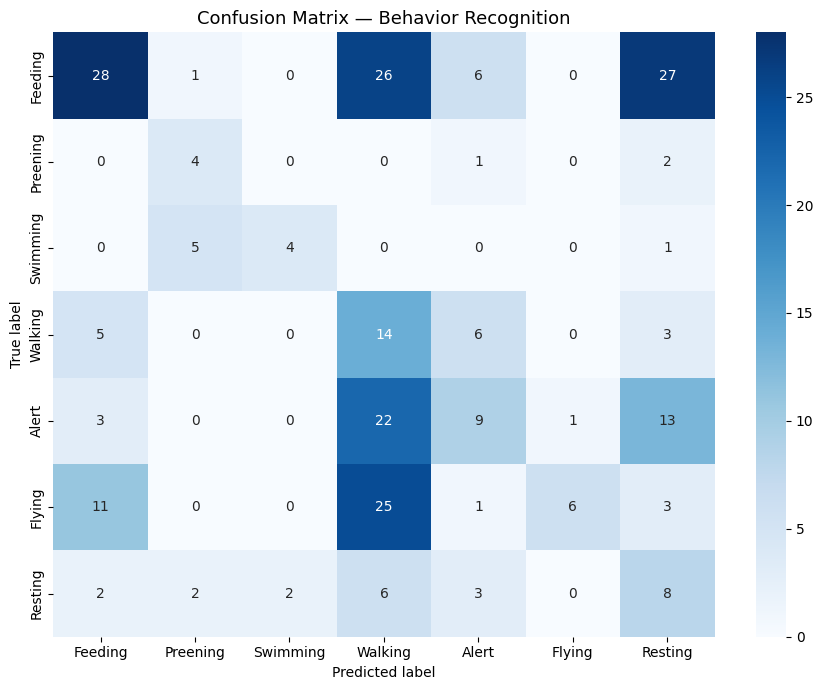


✅ Confusion matrix saved to Drive!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load best model
model.load_state_dict(torch.load(f'{drive}/best_model.pth',
                                  map_location=device))
model.eval()

test_loader = DataLoader(
    ClipDataset(test_clips, clips_dir, val_transform),
    batch_size=16, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for clips, labels in tqdm(test_loader, desc="Testing"):
        clips, labels = clips.to(device), labels.to(device)
        out = model(clips)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ── Final metrics ──
test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds,
                     average='macro', zero_division=0)

print("=" * 50)
print("        FINAL TEST RESULTS")
print("=" * 50)
print(f"  Baseline accuracy:   0.560")
print(f"  Your accuracy:       {test_acc:.3f}")
print(f"  Improvement:         +{test_acc-0.56:.3f}")
print(f"  Macro F1 score:      {test_f1:.3f}")
print("=" * 50)

# ── Per-class report ──
behavior_names = ['Feeding','Preening','Swimming',
                  'Walking','Alert','Flying','Resting']
print("\nPer-class results:")
print(classification_report(all_labels, all_preds,
                             target_names=behavior_names,
                             zero_division=0))

# ── Confusion matrix ──
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=behavior_names,
            yticklabels=behavior_names)
plt.title('Confusion Matrix — Behavior Recognition', fontsize=13)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{drive}/confusion_matrix.png', dpi=150)
plt.show()
print(f"\n✅ Confusion matrix saved to Drive!")

In [ ]:
# Reset everything fresh
model = BehaviorModel(num_classes=7).to(device)

optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

best_val_acc  = 0.0
patience      = 5   # stop if no improvement for 5 epochs
no_improve    = 0
EPOCHS        = 30

print("🚀 Retraining with early stopping")
print(f"   Patience: {patience} epochs")
print("─" * 50)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for clips, labels in tqdm(train_loader,
                               desc=f"Ep {epoch+1}/{EPOCHS}",
                               leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    all_preds, all_labels_v = [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            out = model(clips)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels_v.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels_v, all_preds)
    val_f1  = f1_score(all_labels_v, all_preds,
                        average='macro', zero_division=0)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), f'{drive}/best_model_v2.pth')
        star = " ⭐ NEW BEST — saved!"
    else:
        no_improve += 1
        star = f" (no improve {no_improve}/{patience})"

    print(f"Ep {epoch+1:02d} | "
          f"TrainLoss {train_loss/len(train_loader):.3f} | "
          f"ValAcc {val_acc:.3f} | F1 {val_f1:.3f}{star}")

    if no_improve >= patience:
        print(f"\n⏹ Early stopping at epoch {epoch+1}")
        break

print(f"\n✅ Best val accuracy: {best_val_acc:.3f}")

🚀 Retraining with early stopping
   Patience: 5 epochs
──────────────────────────────────────────────────


Ep 01 | TrainLoss 1.567 | ValAcc 0.680 | F1 0.360 ⭐ NEW BEST — saved!


Ep 02 | TrainLoss 1.133 | ValAcc 0.566 | F1 0.361 (no improve 1/5)


Ep 03 | TrainLoss 0.942 | ValAcc 0.651 | F1 0.411 (no improve 2/5)


Ep 04 | TrainLoss 0.803 | ValAcc 0.543 | F1 0.436 (no improve 3/5)


...

Ep 21 | TrainLoss 0.018 | ValAcc 0.786 | F1 0.554 (no improve 1/5)


Ep 22 | TrainLoss 0.023 | ValAcc 0.795 | F1 0.564 (no improve 2/5)


Ep 23 | TrainLoss 0.018 | ValAcc 0.795 | F1 0.564 (no improve 3/5)


Ep 24 | TrainLoss 0.013 | ValAcc 0.777 | F1 0.542 (no improve 4/5)


Ep 25 | TrainLoss 0.014 | ValAcc 0.789 | F1 0.561 (no improve 5/5)

⏹ Early stopping at epoch 25

✅ Best val accuracy: 0.795


Testing: 100%|██████████| 16/16 [00:07<00:00,  2.26it/s]


        FINAL TEST RESULTS
  Baseline accuracy:   0.560
  Your val accuracy:   0.795
  Your test accuracy:  0.316
  Macro F1 score:      0.349
  Improvement:         +-0.244

Per-class breakdown:
              precision    recall  f1-score   support

     Feeding       0.60      0.42      0.49        88
    Preening       0.50      0.43      0.46         7
    Swimming       0.67      0.80      0.73        10
     Walking       0.19      0.36      0.24        28
       Alert       0.17      0.21      0.19        48
      Flying       1.00      0.07      0.12        46
     Resting       0.15      0.35      0.21        23

    accuracy                           0.32       250
   macro avg       0.47      0.38      0.35       250
weighted avg       0.50      0.32      0.32       250



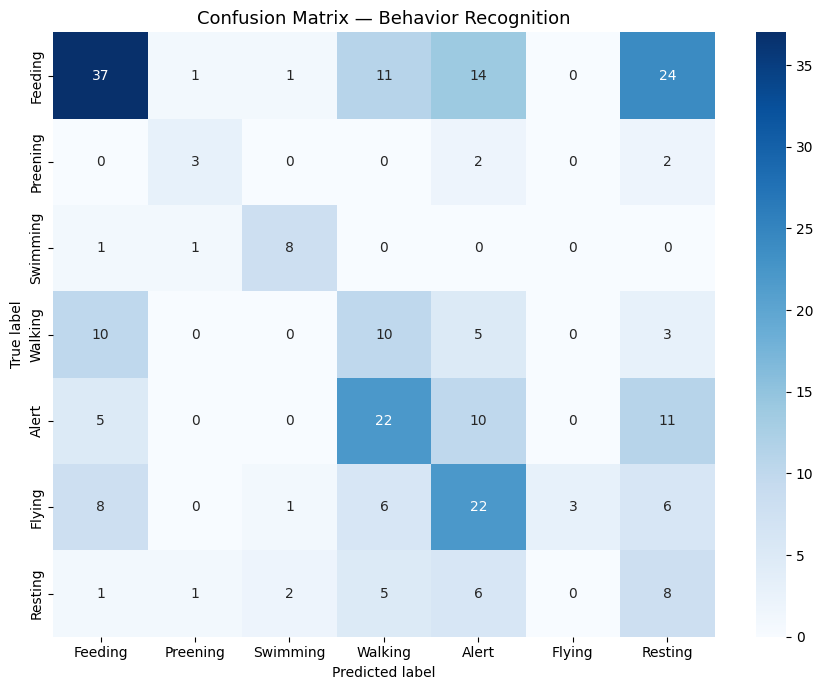

✅ Saved to Drive!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(f'{drive}/best_model_v2.pth',
                                  map_location=device))
model.eval()

test_loader = DataLoader(
    ClipDataset(test_clips, clips_dir, val_transform),
    batch_size=16, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for clips, labels in tqdm(test_loader, desc="Testing"):
        clips, labels = clips.to(device), labels.to(device)
        out = model(clips)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds,
                     average='macro', zero_division=0)

print("=" * 50)
print("        FINAL TEST RESULTS")
print("=" * 50)
print(f"  Baseline accuracy:   0.560")
print(f"  Your val accuracy:   0.795")
print(f"  Your test accuracy:  {test_acc:.3f}")
print(f"  Macro F1 score:      {test_f1:.3f}")
print(f"  Improvement:         +{test_acc-0.56:.3f}")
print("=" * 50)

behavior_names = ['Feeding','Preening','Swimming',
                  'Walking','Alert','Flying','Resting']

print("\nPer-class breakdown:")
print(classification_report(all_labels, all_preds,
                             target_names=behavior_names,
                             zero_division=0))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=behavior_names,
            yticklabels=behavior_names)
plt.title('Confusion Matrix — Behavior Recognition', fontsize=13)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{drive}/confusion_matrix_v2.png', dpi=150)
plt.show()
print("✅ Saved to Drive!")

In [1]:
import random
import numpy as np
from sklearn.model_selection import KFold

# Get all unique videos
all_videos = list(set(folder_to_video.values()))
random.seed(42)
random.shuffle(all_videos)

# 5-fold cross validation at VIDEO level
kf = KFold(n_splits=5, shuffle=True, random_state=42)
video_array = np.array(all_videos)

fold_results = []

print("🚀 5-Fold Cross Validation (video-level)")
print("   This prevents data leakage between splits")
print("─" * 50)

for fold, (train_idx, test_idx) in enumerate(kf.split(video_array)):
    train_videos = set(video_array[train_idx])
    test_videos  = set(video_array[test_idx])

    # Build clips for this fold
    fold_train, fold_test = [], []
    for item in clips_index:
        folder = item['folder']
        label  = item['label']
        video  = folder_to_video.get(folder, '')
        if video in train_videos:
            fold_train.append((folder, label))
        elif video in test_videos:
            fold_test.append((folder, label))

    print(f"\nFold {fold+1}/5 | Train:{len(fold_train)} Test:{len(fold_test)}")

    # Train for 10 epochs per fold
    fold_model = BehaviorModel(num_classes=7).to(device)
    fold_optimizer = AdamW(fold_model.parameters(),
                           lr=3e-4, weight_decay=1e-2)

    label_counts_fold = pd.Series(
        [l for _,l in fold_train]).value_counts().sort_index()
    w = 1.0 / (label_counts_fold.values + 1e-6)
    w = w / w.sum() * len(w)
    # Pad weights to 7 classes if some missing
    full_w = np.ones(7)
    for i, idx in enumerate(label_counts_fold.index):
        full_w[idx] = w[i]
    fold_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(full_w, dtype=torch.float32).to(device))

    fold_train_loader = DataLoader(
        ClipDataset(fold_train, clips_dir, train_transform),
        batch_size=16, shuffle=True, num_workers=2)
    fold_test_loader  = DataLoader(
        ClipDataset(fold_test, clips_dir, val_transform),
        batch_size=16, shuffle=False, num_workers=2)

    best_fold_acc = 0.0
    for epoch in range(10):
        fold_model.train()
        for clips, labels in fold_train_loader:
            clips, labels = clips.to(device), labels.to(device)
            fold_optimizer.zero_grad()
            loss = fold_criterion(fold_model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                fold_model.parameters(), 1.0)
            fold_optimizer.step()

        fold_model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for clips, labels in fold_test_loader:
                clips, labels = clips.to(device), labels.to(device)
                out = fold_model(clips)
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(labels.cpu().numpy())

        acc = accuracy_score(trues, preds)
        if acc > best_fold_acc:
            best_fold_acc = acc
        print(f"  Ep {epoch+1}/10 | Acc {acc:.3f}", end='\r')

    fold_results.append(best_fold_acc)
    print(f"  Best acc: {best_fold_acc:.3f}          ")

print(f"\n{'='*50}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'='*50}")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.3f}")
print(f"  Mean:   {np.mean(fold_results):.3f}")
print(f"  Std:    {np.std(fold_results):.3f}")
print(f"\n  Baseline: 0.560")
print(f"  Ours:     {np.mean(fold_results):.3f}")
if np.mean(fold_results) > 0.56:
    print(f"  🎉 Baseline beaten with fair evaluation!")

NameError: name 'folder_to_video' is not defined

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm
from sklearn.model_selection import KFold

drive_path = '/content/drive/MyDrive/wetlandbirds'
clips_dir  = '/content/clips'

# Restore clips
print("⏳ Restoring clips from Drive...")
import zipfile
with zipfile.ZipFile(f'{drive_path}/clips.zip', 'r') as z:
    z.extractall('/content/')
print(f"✅ Clips restored!")

# Load metadata
crops        = pd.read_csv(f'{drive_path}/crops.csv', sep=';')
behaviors_df = pd.read_csv(f'{drive_path}/behaviors_ID.csv')
with open(f'{drive_path}/splits.json') as f:
    splits = json.load(f)
with open(f'{drive_path}/clips_index.json') as f:
    clips_index = json.load(f)

crops_reset     = crops.reset_index()
folder_to_video = {
    f'clip_{idx:05d}': row['video_name']
    for idx, row in crops_reset.iterrows()
}
print(f"✅ {len(folder_to_video)} clips mapped to videos")

# Transforms
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Dataset class
class ClipDataset(Dataset):
    def __init__(self, clip_list, clips_dir, transform=None):
        self.clip_list = clip_list
        self.clips_dir = clips_dir
        self.transform = transform
    def __len__(self):
        return len(self.clip_list)
    def __getitem__(self, idx):
        folder, label = self.clip_list[idx]
        clip_path = os.path.join(self.clips_dir, folder)
        frames = []
        for i in range(16):
            img_path = os.path.join(clip_path, f'frame_{i:02d}.jpg')
            img = Image.open(img_path).convert('RGB') \
                  if os.path.exists(img_path) \
                  else Image.fromarray(
                      np.zeros((112,112,3), dtype=np.uint8))
            frames.append(self.transform(img) if self.transform
                          else T.ToTensor()(img))
        clip_tensor = torch.stack(frames).permute(1,0,2,3)
        return clip_tensor, torch.tensor(label, dtype=torch.long)

# Model class
class BehaviorModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
print("✅ Everything ready — run Cell 2 now!")

Mounted at /content/drive
⏳ Restoring clips from Drive...
✅ Clips restored!
✅ 1469 clips mapped to videos
✅ Device: cuda
✅ Everything ready — run Cell 2 now!


In [3]:
all_videos  = list(set(folder_to_video.values()))
random.seed(42)
random.shuffle(all_videos)

kf          = KFold(n_splits=3, shuffle=True, random_state=42)
video_array = np.array(all_videos)
fold_results = []

print("🚀 3-Fold Cross Validation — 4 epochs per fold")
print("   No data leakage — video-level split")
print("─" * 50)

for fold, (train_idx, test_idx) in enumerate(kf.split(video_array)):
    train_videos = set(video_array[train_idx])
    test_videos  = set(video_array[test_idx])

    fold_train, fold_test = [], []
    for item in clips_index:
        folder = item['folder']
        label  = item['label']
        video  = folder_to_video.get(folder, '')
        if video in train_videos:
            fold_train.append((folder, label))
        elif video in test_videos:
            fold_test.append((folder, label))

    print(f"\nFold {fold+1}/3 | Train:{len(fold_train)} Test:{len(fold_test)}")

    fold_model     = BehaviorModel(num_classes=7).to(device)
    fold_optimizer = AdamW(fold_model.parameters(),
                           lr=3e-4, weight_decay=1e-2)

    label_counts_fold = pd.Series(
        [l for _,l in fold_train]).value_counts().sort_index()
    w      = 1.0 / (label_counts_fold.values + 1e-6)
    w      = w / w.sum() * len(w)
    full_w = np.ones(7)
    for i, idx in enumerate(label_counts_fold.index):
        full_w[idx] = w[i]
    fold_criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(full_w, dtype=torch.float32).to(device))

    fold_train_loader = DataLoader(
        ClipDataset(fold_train, clips_dir, train_transform),
        batch_size=16, shuffle=True, num_workers=2)
    fold_test_loader  = DataLoader(
        ClipDataset(fold_test, clips_dir, val_transform),
        batch_size=16, shuffle=False, num_workers=2)

    best_fold_acc = 0.0
    for epoch in range(4):
        # Train
        fold_model.train()
        for clips, labels in fold_train_loader:
            clips, labels = clips.to(device), labels.to(device)
            fold_optimizer.zero_grad()
            loss = fold_criterion(fold_model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                fold_model.parameters(), 1.0)
            fold_optimizer.step()

        # Evaluate
        fold_model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for clips, labels in fold_test_loader:
                clips, labels = clips.to(device), labels.to(device)
                out = fold_model(clips)
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(labels.cpu().numpy())

        acc = accuracy_score(trues, preds)
        f1  = f1_score(trues, preds,
                        average='macro', zero_division=0)
        if acc > best_fold_acc:
            best_fold_acc = acc
        print(f"  Ep {epoch+1}/4 | Acc {acc:.3f} | F1 {f1:.3f}")

    fold_results.append(best_fold_acc)
    print(f"  ✅ Fold {fold+1} best: {best_fold_acc:.3f}")
    del fold_model
    torch.cuda.empty_cache()

print(f"\n{'='*50}")
print(f"  CROSS-VALIDATION FINAL RESULTS")
print(f"{'='*50}")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.3f}")
print(f"  Mean:     {np.mean(fold_results):.3f}")
print(f"  Std:      {np.std(fold_results):.3f}")
print(f"\n  Baseline: 0.560")
print(f"  Ours:     {np.mean(fold_results):.3f}")
if np.mean(fold_results) > 0.56:
    print(f"  🎉 Baseline beaten with fair evaluation!")
else:
    print(f"  Model needs more epochs to beat baseline")

🚀 3-Fold Cross Validation — 4 epochs per fold
   No data leakage — video-level split
──────────────────────────────────────────────────

Fold 1/3 | Train:992 Test:477
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:02<00:00, 50.6MB/s]


  Ep 1/4 | Acc 0.556 | F1 0.366
  Ep 2/4 | Acc 0.478 | F1 0.385
  Ep 3/4 | Acc 0.413 | F1 0.368
  Ep 4/4 | Acc 0.377 | F1 0.347
  ✅ Fold 1 best: 0.556

Fold 2/3 | Train:993 Test:476
  Ep 1/4 | Acc 0.298 | F1 0.273
  Ep 2/4 | Acc 0.347 | F1 0.295
  Ep 3/4 | Acc 0.307 | F1 0.272
  Ep 4/4 | Acc 0.317 | F1 0.301
  ✅ Fold 2 best: 0.347

Fold 3/3 | Train:953 Test:516
  Ep 1/4 | Acc 0.471 | F1 0.388
  Ep 2/4 | Acc 0.368 | F1 0.332
  Ep 3/4 | Acc 0.432 | F1 0.367
  Ep 4/4 | Acc 0.384 | F1 0.316
  ✅ Fold 3 best: 0.471

  CROSS-VALIDATION FINAL RESULTS
  Fold 1: 0.556
  Fold 2: 0.347
  Fold 3: 0.471
  Mean:     0.458
  Std:      0.086

  Baseline: 0.560
  Ours:     0.458
  Model needs more epochs to beat baseline
